In [197]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import missingno as msno

pd.set_option('display.max_columns', 200)

In [198]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Personal/asteroid_project/data/processed/asteroids.csv')

In [199]:
df.shape

(1477090, 38)

In [200]:
df.head()

,H,G,Num_obs,rms,U,Arc_years,Perturbers,Perturbers_2,Number,Name,Principal_desig,Other_desigs,Epoch,M,Peri,Node,i,e,n,a,Ref,Num_opps,Computer,Hex_flags,Last_obs,Tp,Orbital_period,Perihelion_dist,Aphelion_dist,Semilatus_rectum,Synodic_period,Orbit_type,NEO_flag,One_km_NEO_flag,PHA_flag,One_opposition_object_flag,Arc_length,hazerdous
0,18.31,0.15,101.0,0.90,0,2003-2025,M-v,3Ek,(440131),NaN,2003 SR329,NaN,2461000.5,98.01667,21.29490,20.45607,2.17419,0.220580,0.236456,2.590018,MPO891325,7,MPCLINUX,0000,2025-01-02,2.460586e+06,4.168255,2.018711,3.161326,1.231999,1.315631,MBA,NaN,NaN,NaN,NaN,NaN,0
1,17.14,0.15,250.0,0.89,0,2005-2024,M-v,3Ek,(596642),NaN,2005 YC185,"['2010 CY86', '2012 UW121', '2014 FL44']",2461000.5,245.12922,329.93421,318.53094,4.99459,0.125079,0.255371,2.460490,MPO892149,13,MPCLINUX,0000,2024-12-20,2.461450e+06,3.859512,2.152733,2.768246,1.210998,1.349710,MBA,NaN,NaN,NaN,NaN,NaN,0
2,17.12,0.15,213.0,0.99,0,2008-2025,M-v,3Ek,(484515),NaN,2008 EL51,NaN,2461000.5,7.73489,333.54655,190.29557,15.46781,0.250532,0.222208,2.699581,MPO905048,9,MPCLINUX,0000,2025-01-26,2.460966e+06,4.435521,2.023249,3.375913,1.265069,1.291077,MBA,NaN,NaN,NaN,NaN,NaN,0
3,18.15,0.15,206.0,0.95,0,2002-2025,M-v,3Ek,(660520),NaN,2002 AC173,NaN,2461000.5,227.02952,5.59939,113.34616,2.06068,0.138080,0.273783,2.348900,MPO954653,12,MPCORBFIT,0000,2025-08-16,2.461486e+06,3.599953,2.024565,2.673236,1.152058,1.384622,MBA,NaN,NaN,NaN,NaN,NaN,0
4,15.36,0.15,1119.0,0.81,0,2001-2025,M-v,3Ek,(188731),NaN,2005 US54,NaN,2461000.5,296.32977,319.59282,28.96358,14.85383,0.166574,0.230973,2.630845,MPO927334,18,MPCLINUX,0000,2025-06-14,2.461276e+06,4.267199,2.192614,3.069076,1.278924,1.306072,MBA,NaN,NaN,NaN,NaN,NaN,0


In [201]:
df.columns

Index(['H', 'G', 'Num_obs', 'rms', 'U', 'Arc_years', 'Perturbers',
       'Perturbers_2', 'Number', 'Name', 'Principal_desig', 'Other_desigs',
       'Epoch', 'M', 'Peri', 'Node', 'i', 'e', 'n', 'a', 'Ref', 'Num_opps',
       'Computer', 'Hex_flags', 'Last_obs', 'Tp', 'Orbital_period',
       'Perihelion_dist', 'Aphelion_dist', 'Semilatus_rectum',
       'Synodic_period', 'Orbit_type', 'NEO_flag', 'One_km_NEO_flag',
       'PHA_flag', 'One_opposition_object_flag', 'Arc_length', 'hazerdous'],
      dtype='object')

In [202]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1477090 entries, 0 to 1477089
Data columns (total 38 columns):
 #   Column                      Non-Null Count    Dtype  
---  ------                      --------------    -----  
 0   H                           1476907 non-null  float64
 1   G                           1476907 non-null  float64
 2   Num_obs                     1477088 non-null  float64
 3   rms                         1477064 non-null  float64
 4   U                           1466709 non-null  object 
 5   Arc_years                   1302885 non-null  object 
 6   Perturbers                  1465477 non-null  object 
 7   Perturbers_2                1465477 non-null  object 
 8   Number                      875150 non-null   object 
 9   Name                        25716 non-null    object 
 10  Principal_desig             1477090 non-null  object 
 11  Other_desigs                388414 non-null   object 
 12  Epoch                       1477090 non-null  float64
 1

In [203]:
df.select_dtypes(include='object')

,U,Arc_years,Perturbers,Perturbers_2,Number,Name,Principal_desig,Other_desigs,Ref,Computer,Hex_flags,Last_obs,Orbit_type
0,0,2003-2025,M-v,3Ek,(440131),NaN,2003 SR329,NaN,MPO891325,MPCLINUX,0000,2025-01-02,MBA
1,0,2005-2024,M-v,3Ek,(596642),NaN,2005 YC185,"['2010 CY86', '2012 UW121', '2014 FL44']",MPO892149,MPCLINUX,0000,2024-12-20,MBA
2,0,2008-2025,M-v,3Ek,(484515),NaN,2008 EL51,NaN,MPO905048,MPCLINUX,0000,2025-01-26,MBA
3,0,2002-2025,M-v,3Ek,(660520),NaN,2002 AC173,NaN,MPO954653,MPCORBFIT,0000,2025-08-16,MBA
4,0,2001-2025,M-v,3Ek,(188731),NaN,2005 US54,NaN,MPO927334,MPCLINUX,0000,2025-06-14,MBA
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1477085,0,1977-2025,M-v,3Ek,(259474),NaN,2003 SX169,NaN,MPO916193,MPCLINUX,0000,2025-05-15,MBA
1477086,1,2007-2025,M-v,3Ek,NaN,NaN,2023 VP11,NaN,MPO907375,MPCLINUX,0008,2025-01-22,Hilda
1477087,0,1998-2025,M-v,3Ek,(132045),NaN,2002 CY132,NaN,MPO952068,MPCORBFIT,0000,2025-09-15,MBA
1477088,0,2005-2024,M-v,3Ek,(671984),NaN,2014 QU324,['2016 AP15'],MPO892538,MPCLINUX,0000,2024-12-23,MBA


In [204]:
for col in df.select_dtypes(include='object'):
  if col not in ['Arc_years', 'Number', 'Name', 'Principal_desig', 'Other_desigs', 'Ref', 'Computer', 'Last_obs']:
    print(f'unique values for {col}: {df[col].unique()}')

unique values for U: ['0' '6' '1' '8' '5' '2' '7' '9' '3' nan '4' 'E' 'D']
unique values for Perturbers: ['M-v' nan 'M-h' 'M-N' 'M-c' 'M-p']
unique values for Perturbers_2: ['3Ek' '3El' '38h' nan '3Eh' '08' '30k' '28k' '08h' '18k']
unique values for Hex_flags: ['0000' '2000' '0009' '0006' '2007' '000A' '0005' '2802' '2804' '0007'
 '0803' '200A' '2005' '2803' '0008' '8803' '2009' '8804' '2006' '0804'
 '0400' '1804' '1803' '0406' '9803' 'A804' '0802' '8802' '2008' 'A803'
 '3804' '0405' '1802' '040A' 'A802' '0408' '1801' '2801' '3803' '8801'
 '0801' '0C04' '9804' '0407' '0C03' 'B803' '9802' '8C04' '4007' '4000'
 '0C02' '280A' '080A' '0409' '8C02']
unique values for Orbit_type: ['MBA' 'Jupiter Trojan' 'Hungaria' 'Phocaea' 'Distant Object'
 'Object with perihelion distance < 1.665 AU' 'Aten' 'Amor' 'Apollo'
 'Hilda' 'Atira']


In [205]:
df.select_dtypes(include=['int64', 'float64'])

,H,G,Num_obs,rms,Epoch,M,Peri,Node,i,e,n,a,Num_opps,Tp,Orbital_period,Perihelion_dist,Aphelion_dist,Semilatus_rectum,Synodic_period,NEO_flag,One_km_NEO_flag,PHA_flag,One_opposition_object_flag,Arc_length,hazerdous
0,18.31,0.15,101.0,0.90,2461000.5,98.01667,21.29490,20.45607,2.17419,0.220580,0.236456,2.590018,7,2.460586e+06,4.168255,2.018711,3.161326,1.231999,1.315631,NaN,NaN,NaN,NaN,NaN,0
1,17.14,0.15,250.0,0.89,2461000.5,245.12922,329.93421,318.53094,4.99459,0.125079,0.255371,2.460490,13,2.461450e+06,3.859512,2.152733,2.768246,1.210998,1.349710,NaN,NaN,NaN,NaN,NaN,0
2,17.12,0.15,213.0,0.99,2461000.5,7.73489,333.54655,190.29557,15.46781,0.250532,0.222208,2.699581,9,2.460966e+06,4.435521,2.023249,3.375913,1.265069,1.291077,NaN,NaN,NaN,NaN,NaN,0
3,18.15,0.15,206.0,0.95,2461000.5,227.02952,5.59939,113.34616,2.06068,0.138080,0.273783,2.348900,12,2.461486e+06,3.599953,2.024565,2.673236,1.152058,1.384622,NaN,NaN,NaN,NaN,NaN,0
4,15.36,0.15,1119.0,0.81,2461000.5,296.32977,319.59282,28.96358,14.85383,0.166574,0.230973,2.630845,18,2.461276e+06,4.267199,2.192614,3.069076,1.278924,1.306072,NaN,NaN,NaN,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1477085,16.80,0.15,670.0,0.87,2461000.5,340.63291,78.86674,221.01017,6.01269,0.123230,0.302369,2.198424,17,2.461065e+06,3.259622,1.927511,2.469337,1.082520,1.442552,NaN,NaN,NaN,NaN,NaN,0
1477086,16.98,0.15,33.0,0.43,2461000.5,92.19696,311.33257,106.21730,4.29026,0.177540,0.124562,3.970799,6,2.460260e+06,7.912557,3.265822,4.675776,1.922818,1.144664,NaN,NaN,NaN,NaN,NaN,0
1477087,16.79,0.15,598.0,0.80,2461000.5,107.25030,27.72002,194.96491,0.79093,0.135780,0.267411,2.386068,18,2.460599e+06,3.685737,2.062087,2.710050,1.171039,1.372337,NaN,NaN,NaN,NaN,NaN,0
1477088,17.54,0.15,136.0,0.88,2461000.5,164.74466,238.79382,81.82374,3.15423,0.069401,0.206451,2.835250,10,2.460203e+06,4.774052,2.638480,3.032020,1.410797,1.264967,NaN,NaN,NaN,NaN,NaN,0


In [206]:
df.describe().round(3)

,H,G,Num_obs,rms,Epoch,M,Peri,Node,i,e,n,a,Num_opps,Tp,Orbital_period,Perihelion_dist,Aphelion_dist,Semilatus_rectum,Synodic_period,NEO_flag,One_km_NEO_flag,PHA_flag,One_opposition_object_flag,Arc_length,hazerdous
count,1476907.000,1476907.000,1477088.000,1477064.000,1477090.000,1477090.000,1477090.000,1477090.000,1477090.000,1477090.000,1477090.000,1477090.000,1477090.000,1477090.000,1477090.000,1477090.000,1477090.000,1477090.000,1477090.000,39876.0,1407.0,2510.0,161861.0,174205.000,1477090.000
mean,17.575,0.150,328.718,0.664,2460963.331,177.873,181.822,169.550,9.346,0.159,0.235,2.913,9.123,2460940.396,6.863,2.408,3.417,1.384,1.394,1.0,1.0,1.0,1.0,26.358,0.002
std,1.941,0.001,686.929,0.261,448.332,104.644,103.784,102.879,6.659,0.095,0.084,6.869,6.354,1513.796,298.293,2.186,12.866,1.311,5.588,0.0,0.0,0.0,0.0,26.533,0.041
min,-1.250,0.000,2.000,0.000,2425067.500,0.000,0.000,0.000,0.003,0.000,0.000,0.462,1.000,2340708.113,0.314,0.070,0.654,0.069,0.457,1.0,1.0,1.0,1.0,0.000,0.000
25%,16.660,0.150,42.000,0.420,2461000.500,86.989,91.885,81.566,4.410,0.093,0.187,2.398,4.000,2460592.772,3.714,1.971,2.803,1.160,1.234,1.0,1.0,1.0,1.0,6.000,0.000
50%,17.570,0.150,103.000,0.750,2461000.500,176.050,183.626,161.277,7.938,0.148,0.226,2.666,8.000,2460977.605,4.353,2.241,3.084,1.292,1.298,1.0,1.0,1.0,1.0,21.000,0.000
75%,18.450,0.150,296.000,0.880,2461000.500,268.617,271.672,254.772,12.732,0.205,0.265,3.027,13.000,2461374.771,5.266,2.591,3.397,1.472,1.368,1.0,1.0,1.0,1.0,36.000,0.000
max,99.990,0.150,18486.000,9.990,2461000.500,360.000,360.000,359.999,175.976,0.997,3.141,4225.555,126.000,2667683.375,274679.146,80.636,8427.388,70.936,5533.337,1.0,1.0,1.0,1.0,262.000,1.000


<Figure size 1200x600 with 0 Axes>

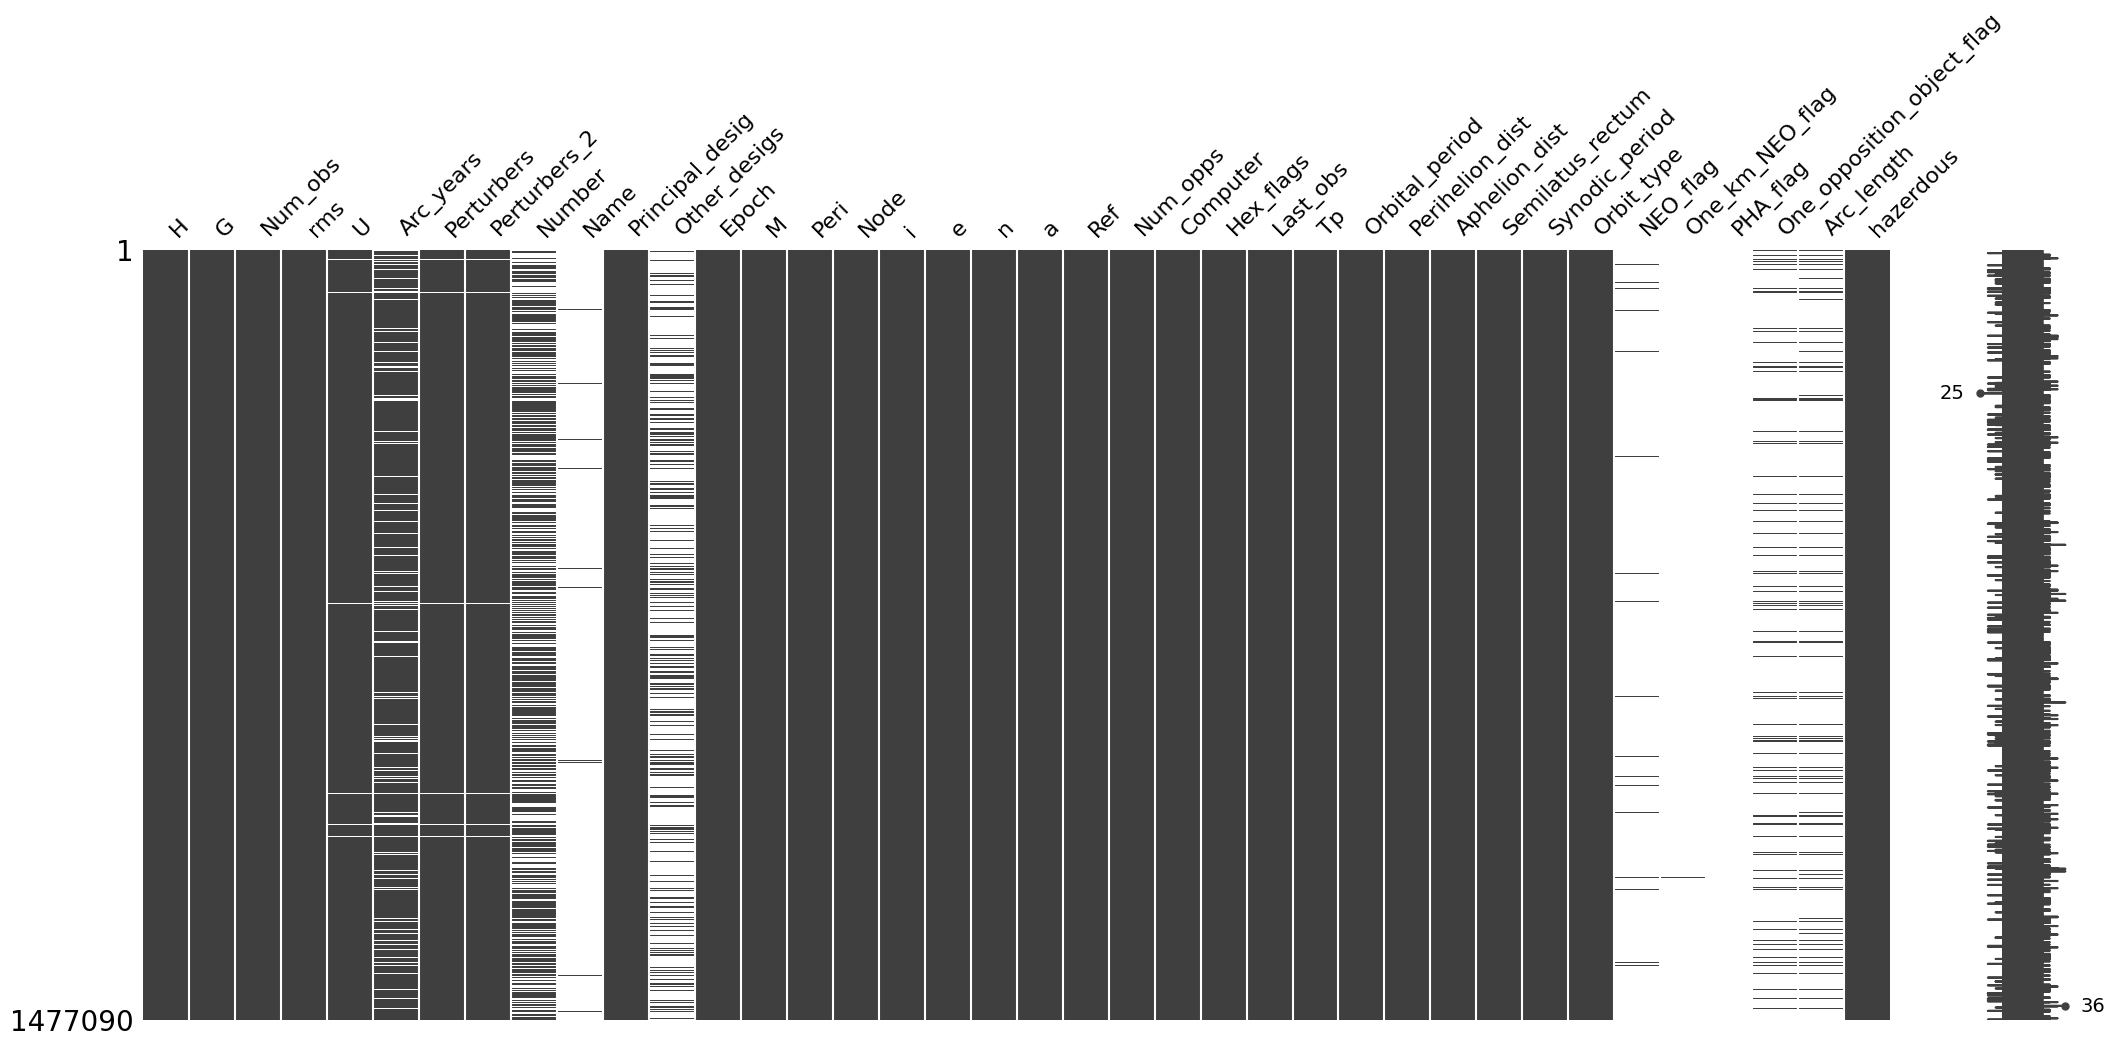

In [207]:
plt.figure(figsize=(12, 6))
msno.matrix(df)
plt.show()

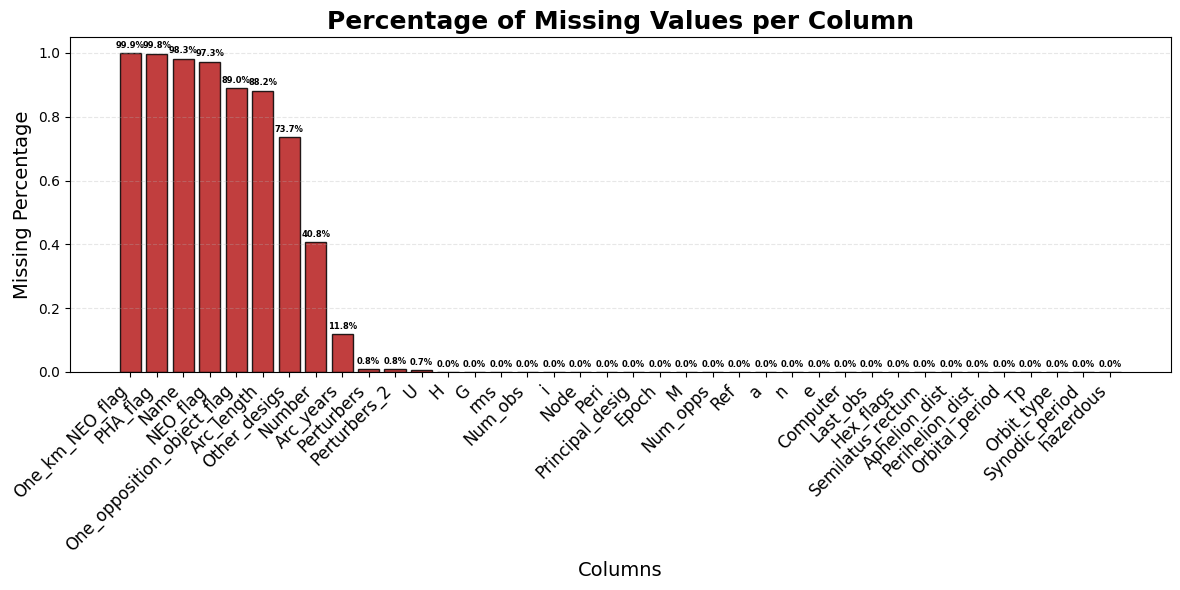

In [208]:
missing_percent = df.isna().sum().sort_values(ascending=False) / df.shape[0]


plt.figure(figsize=(12,6))
bars = plt.bar(
    missing_percent.index,
    missing_percent.values,
    color="#B71C1C",
    edgecolor="black",
    alpha=0.85
)

plt.xticks(rotation=45, ha='right', fontsize=12)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.01,
        f'{height:.1%}',
        ha='center',
        va='bottom',
        fontsize=6,
        fontweight='bold'
    )

plt.title("Percentage of Missing Values per Column", fontsize=18, fontweight="bold")
plt.xlabel("Columns", fontsize=14)
plt.ylabel("Missing Percentage", fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()


In [209]:
df.duplicated().sum()

np.int64(0)

In [210]:
df.duplicated(subset='Principal_desig').sum()

np.int64(0)

## Classification & Flags

| Column | Meaning |
|--------|---------|
| **Orbit_type** | Taxonomy such as: MBA (Main-belt asteroid), APO (Apollo), AMO (Amor), ATE (Aten), etc. |
| **NEO_flag** | Near-Earth Object (1 = yes). |
| **One_km_NEO_flag** | NEO estimated to be >1 km in diameter. |
| **PHA_flag** | Potentially Hazardous Asteroid (1 = yes). |

---


## Asteroid Identification

| Column | Meaning |
|--------|---------|
| **Number** | Asteroid’s assigned number (e.g., 433 for Eros). Only well-known asteroids have a number. |
| **Name** | Asteroid name (very few have this). |
| **Principal_desig** | Primary designation (e.g., 2021 AB). |
| **Other_desigs** | Additional designations or aliases. |

---


## Metadata

| Column | Meaning |
|--------|---------|
| **Ref** | Orbit computation reference code. |
| **Num_opps** | Number of oppositions observed. |
| **Computer** | Software/system that computed the orbit. |
| **Hex_flags** | Internal hexadecimal flags for orbit processing. |
| **Last_obs** | Date of last observation (YYYY-MM-DD). |

## Perturbers

| Column | Meaning |
|--------|---------|
| **Perturbers** | Planetary perturbers included in orbit solution (e.g., “M-v” means Moon & Venus). |
| **Perturbers_2** | Secondary perturber list (MPC format sometimes splits this). |

---


In [211]:
df.drop(['NEO_flag','Perturbers', 'Perturbers_2', 'Number', 'Name', 'Principal_desig',
 'Other_desigs', 'Ref', 'Computer', 'Hex_flags', 'Last_obs',
 'One_km_NEO_flag', 'PHA_flag', 'One_opposition_object_flag', 'Arc_length'],
        axis=1,
        inplace=True
        )

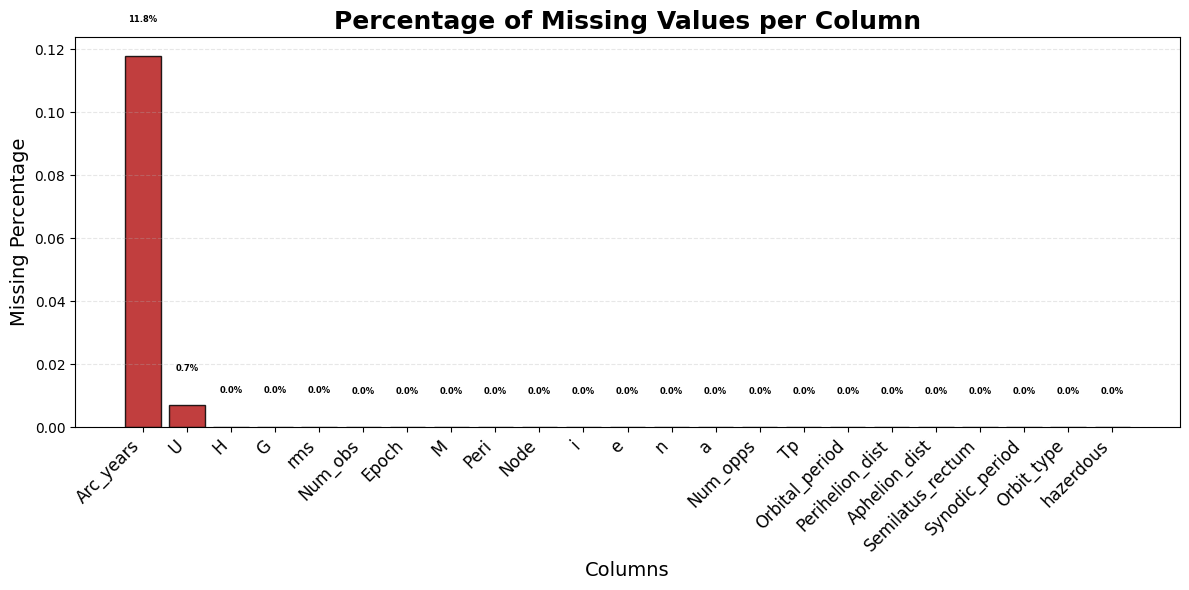

In [212]:
missing_percent = df.isna().sum().sort_values(ascending=False) / df.shape[0]


plt.figure(figsize=(12,6))
bars = plt.bar(
    missing_percent.index,
    missing_percent.values,
    color="#B71C1C",
    edgecolor="black",
    alpha=0.85
)

plt.xticks(rotation=45, ha='right', fontsize=12)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.01,
        f'{height:.1%}',
        ha='center',
        va='bottom',
        fontsize=6,
        fontweight='bold'
    )

plt.title("Percentage of Missing Values per Column", fontsize=18, fontweight="bold")
plt.xlabel("Columns", fontsize=14)
plt.ylabel("Missing Percentage", fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()


In [213]:
df['Arc_years'].head(5)

,Arc_years
0,2003-2025
1,2005-2024
2,2008-2025
3,2002-2025
4,2001-2025


In [214]:
def transform_arc_years(val):
    if pd.isna(val):
        return np.nan

    val = str(val).strip()
    if val == "" or val.lower() == "none":
        return np.nan

    parts = val.split('-')


    try:
        start = float(parts[0]) if parts[0] != "" else np.nan
        end = float(parts[1]) if len(parts) > 1 and parts[1] != "" else np.nan
    except:
        return np.nan


    if pd.isna(start) and pd.isna(end):
        return np.nan


    if pd.isna(start) or pd.isna(end):
        return np.nan

    return end - start

df['Arc_years'] = df['Arc_years'].apply(transform_arc_years)


In [215]:
print(df['U'].sort_values().unique())

['0' '1' '2' '3' '4' '5' '6' '7' '8' '9' 'D' 'E' nan]


In [216]:
def transform_U(val):
    if pd.isna(val):
        return np.nan
    val = str(val).strip()
    if val == "" or val.lower() == "none":
        return np.nan
    elif val.upper() == 'E' or val.upper() == 'D':
      return 9
    else:
      return int(val)

df['U'] = df['U'].apply(transform_U)

In [217]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1477090 entries, 0 to 1477089
Data columns (total 23 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   H                 1476907 non-null  float64
 1   G                 1476907 non-null  float64
 2   Num_obs           1477088 non-null  float64
 3   rms               1477064 non-null  float64
 4   U                 1466709 non-null  float64
 5   Arc_years         1302885 non-null  float64
 6   Epoch             1477090 non-null  float64
 7   M                 1477090 non-null  float64
 8   Peri              1477090 non-null  float64
 9   Node              1477090 non-null  float64
 10  i                 1477090 non-null  float64
 11  e                 1477090 non-null  float64
 12  n                 1477090 non-null  float64
 13  a                 1477090 non-null  float64
 14  Num_opps          1477090 non-null  int64  
 15  Tp                1477090 non-null  float64
 16  

In [218]:
df.isna().sum()

,0
H,183
G,183
Num_obs,2
rms,26
U,10381
Arc_years,174205
Epoch,0
M,0
Peri,0
Node,0


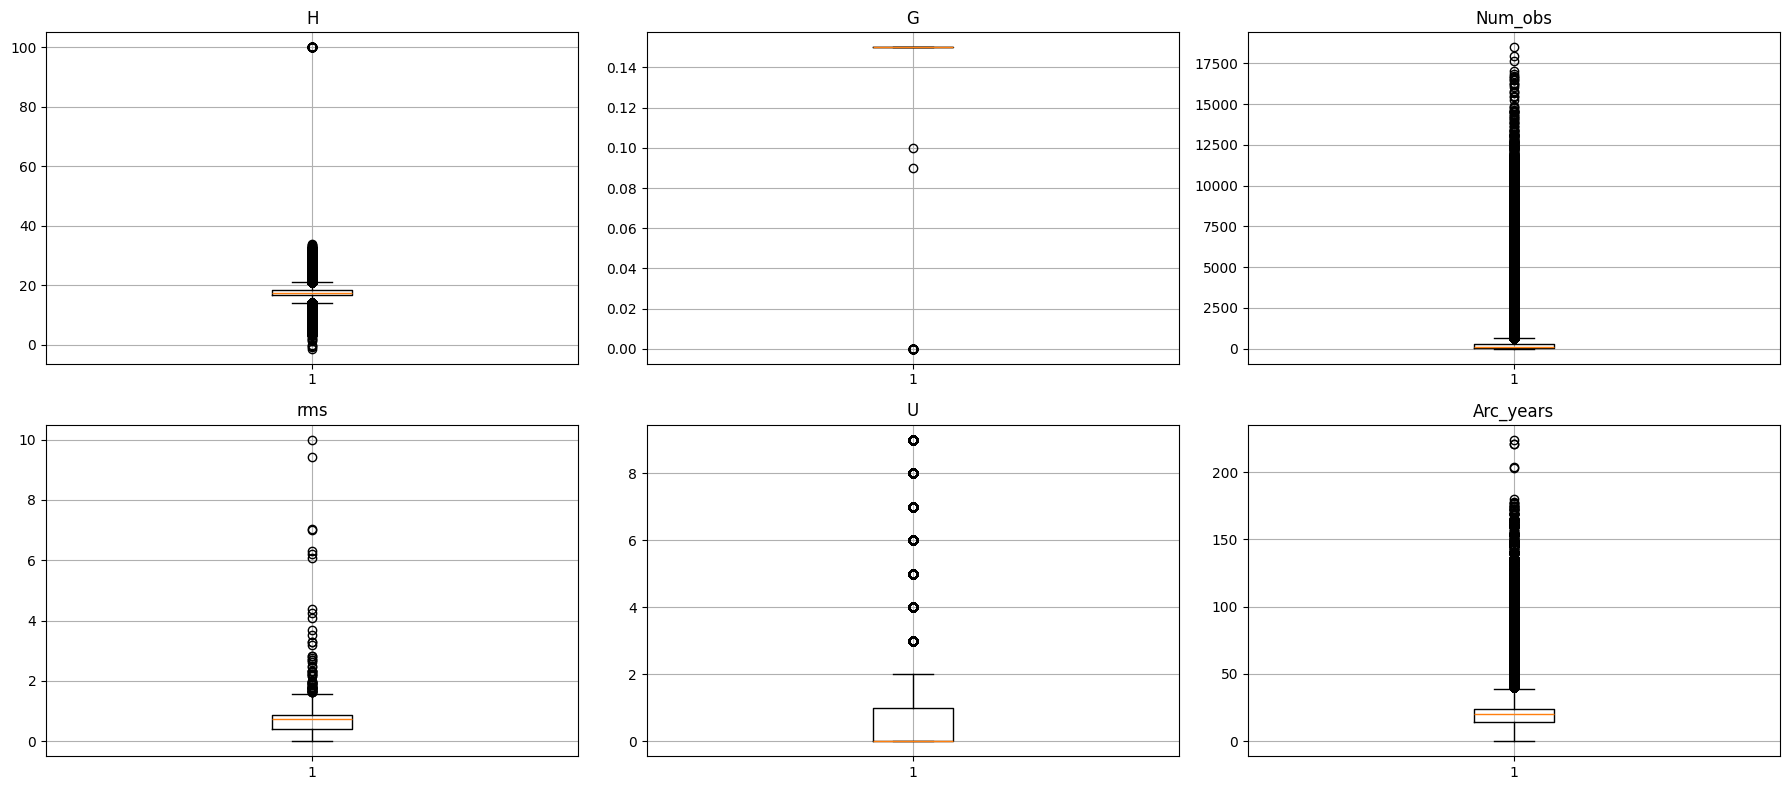

In [219]:
cols_with_missing = ['H', 'G', 'Num_obs', 'rms', 'U', 'Arc_years']

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(cols_with_missing):
    axes[i].boxplot(df[col].dropna(), vert=True)
    axes[i].set_title(col)
    axes[i].grid(True)

plt.tight_layout()
plt.show()


In [220]:
for col in cols_with_missing:
  df[col].fillna(df[col].median(), inplace=True)

/tmp/ipython-input-18101768.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [221]:
df.isna().sum()

,0
H,0
G,0
Num_obs,0
rms,0
U,0
Arc_years,0
Epoch,0
M,0
Peri,0
Node,0


In [222]:
df.head(5)

,H,G,Num_obs,rms,U,Arc_years,Epoch,M,Peri,Node,i,e,n,a,Num_opps,Tp,Orbital_period,Perihelion_dist,Aphelion_dist,Semilatus_rectum,Synodic_period,Orbit_type,hazerdous
0,18.31,0.15,101.0,0.90,0.0,22.0,2461000.5,98.01667,21.29490,20.45607,2.17419,0.220580,0.236456,2.590018,7,2.460586e+06,4.168255,2.018711,3.161326,1.231999,1.315631,MBA,0
1,17.14,0.15,250.0,0.89,0.0,19.0,2461000.5,245.12922,329.93421,318.53094,4.99459,0.125079,0.255371,2.460490,13,2.461450e+06,3.859512,2.152733,2.768246,1.210998,1.349710,MBA,0
2,17.12,0.15,213.0,0.99,0.0,17.0,2461000.5,7.73489,333.54655,190.29557,15.46781,0.250532,0.222208,2.699581,9,2.460966e+06,4.435521,2.023249,3.375913,1.265069,1.291077,MBA,0
3,18.15,0.15,206.0,0.95,0.0,23.0,2461000.5,227.02952,5.59939,113.34616,2.06068,0.138080,0.273783,2.348900,12,2.461486e+06,3.599953,2.024565,2.673236,1.152058,1.384622,MBA,0
4,15.36,0.15,1119.0,0.81,0.0,24.0,2461000.5,296.32977,319.59282,28.96358,14.85383,0.166574,0.230973,2.630845,18,2.461276e+06,4.267199,2.192614,3.069076,1.278924,1.306072,MBA,0


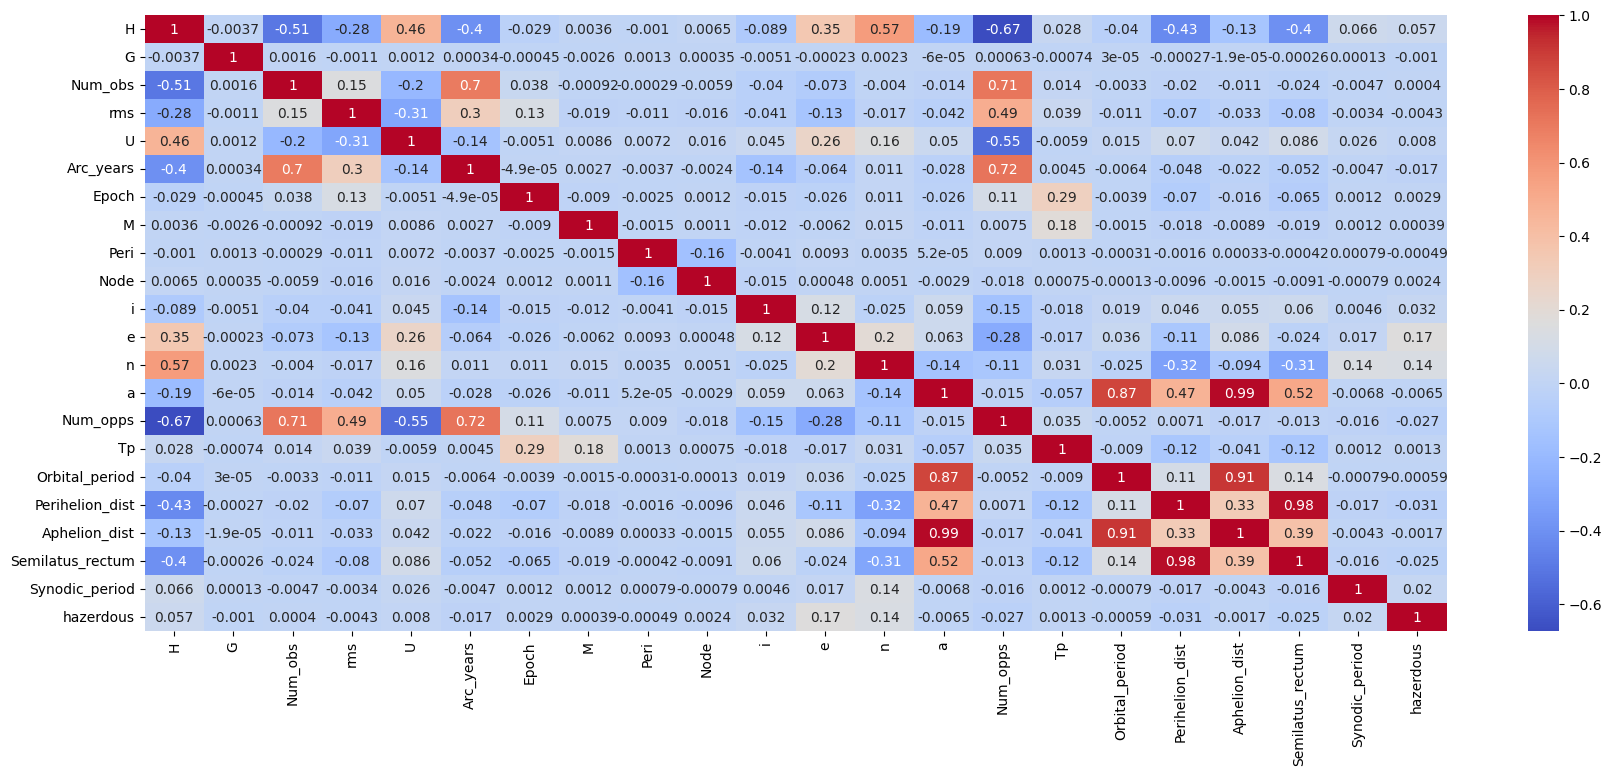

In [223]:
plt.figure(figsize=(21, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

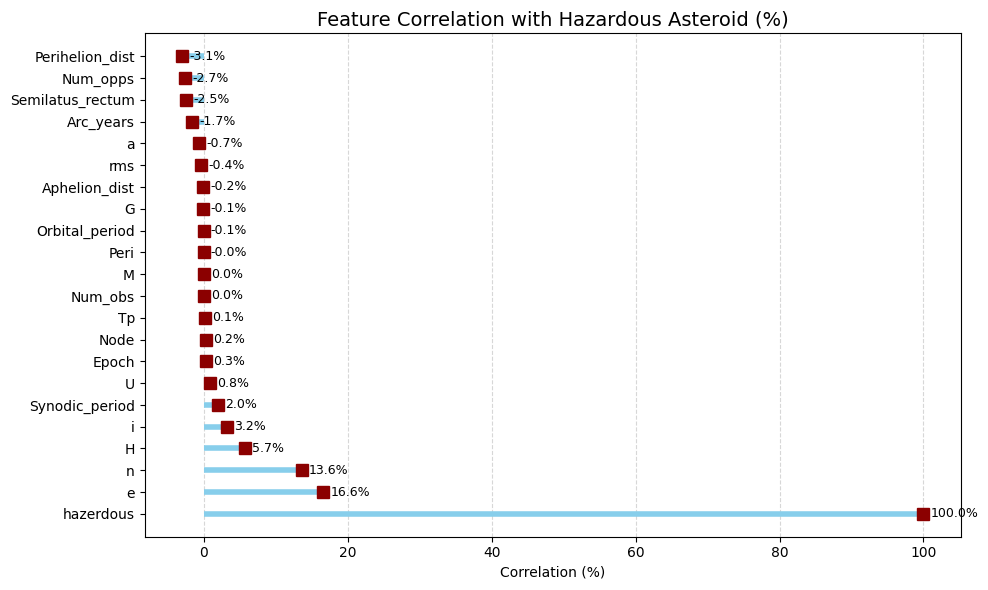

In [224]:
c = df.corr(numeric_only=True)['hazerdous'].sort_values(ascending=False)

c_percent = c * 100

plt.figure(figsize=(10,6))

plt.hlines(y=c_percent.index, xmin=0, xmax=c_percent.values, color='skyblue', linewidth=4)

plt.plot(c_percent.values, c_percent.index, "s", color='darkred', markersize=8)

for x, y in zip(c_percent.values, c_percent.index):
    plt.text(x + 1, y, f"{x:.1f}%", va='center', fontsize=9)

plt.title('Feature Correlation with Hazardous Asteroid (%)', fontsize=14)
plt.xlabel('Correlation (%)')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


## Derived Orbital Parameters

- **Orbital_period** — Orbital period. Units depend on the dataset.
- **Perihelion_dist** — Closest distance to the Sun. q = a(1 − e).
- **Aphelion_dist** — Farthest distance from the Sun. Q = a(1 + e).
- **Semilatus_rectum** — Semi‑latus rectum. p = a(1 − e^2).
- **Synodic_period** — Time between successive oppositions as seen from Earth.


In [225]:
df.columns

Index(['H', 'G', 'Num_obs', 'rms', 'U', 'Arc_years', 'Epoch', 'M', 'Peri',
       'Node', 'i', 'e', 'n', 'a', 'Num_opps', 'Tp', 'Orbital_period',
       'Perihelion_dist', 'Aphelion_dist', 'Semilatus_rectum',
       'Synodic_period', 'Orbit_type', 'hazerdous'],
      dtype='object')

In [226]:
df.drop(['Epoch','Tp' ,'Orbital_period', 'Perihelion_dist', 'Semilatus_rectum', 'Aphelion_dist'],
        axis=1,
        inplace=True
        )

In [227]:
df.head(5)

,H,G,Num_obs,rms,U,Arc_years,M,Peri,Node,i,e,n,a,Num_opps,Synodic_period,Orbit_type,hazerdous
0,18.31,0.15,101.0,0.90,0.0,22.0,98.01667,21.29490,20.45607,2.17419,0.220580,0.236456,2.590018,7,1.315631,MBA,0
1,17.14,0.15,250.0,0.89,0.0,19.0,245.12922,329.93421,318.53094,4.99459,0.125079,0.255371,2.460490,13,1.349710,MBA,0
2,17.12,0.15,213.0,0.99,0.0,17.0,7.73489,333.54655,190.29557,15.46781,0.250532,0.222208,2.699581,9,1.291077,MBA,0
3,18.15,0.15,206.0,0.95,0.0,23.0,227.02952,5.59939,113.34616,2.06068,0.138080,0.273783,2.348900,12,1.384622,MBA,0
4,15.36,0.15,1119.0,0.81,0.0,24.0,296.32977,319.59282,28.96358,14.85383,0.166574,0.230973,2.630845,18,1.306072,MBA,0


In [228]:
df['Orbit_type'].replace('Object with perihelion distance < 1.665 AU', 'perihelion < 1.665 AU', inplace=True)

/tmp/ipython-input-1080812975.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Orbit_type'].replace('Object with perihelion distance < 1.665 AU', 'perihelion < 1.665 AU', inplace=True)


### Distribution of Orbit Type

In [229]:
hazardous = df[df['hazerdous'] == 1]

uncertain = df[df['hazerdous'] == 0]

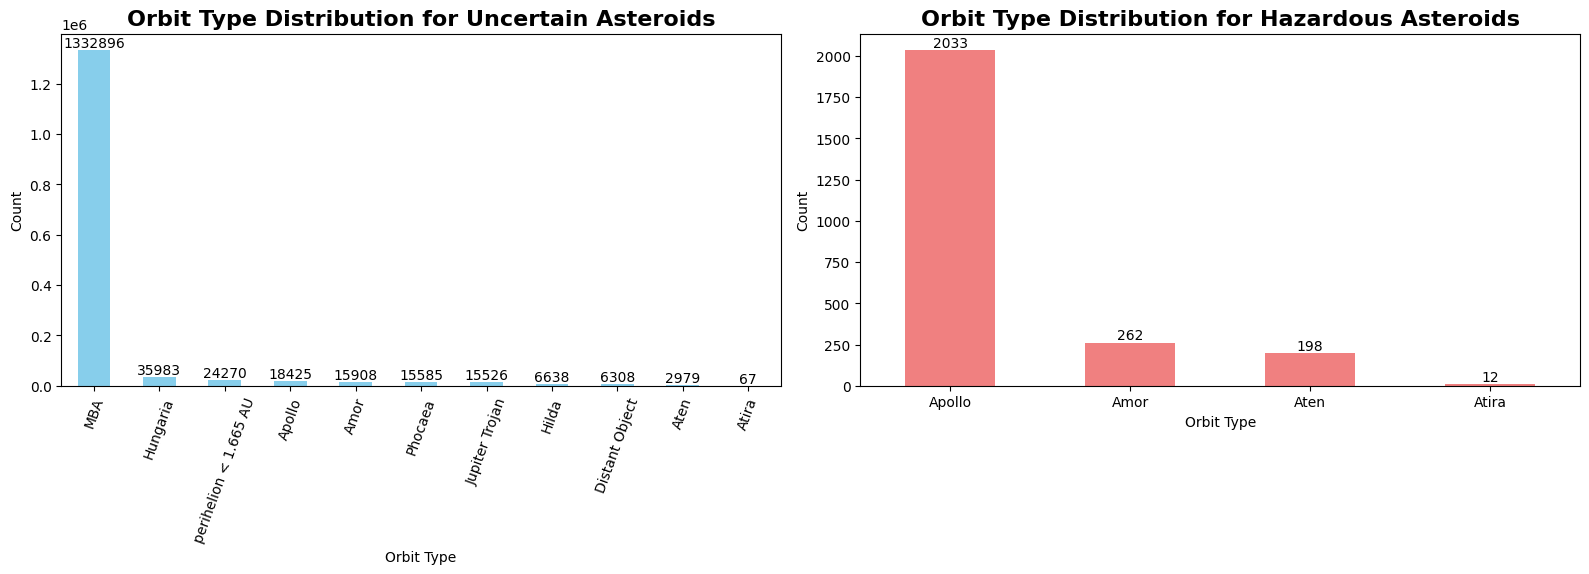

In [230]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))


uncertain['Orbit_type'].value_counts().plot(
    kind='bar', ax=axes[0], color='skyblue'
)
axes[0].set_title('Orbit Type Distribution for Uncertain Asteroids',
                  fontweight='bold',
                  fontsize=16
                  )
axes[0].set_xlabel('Orbit Type')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=70)

hazardous['Orbit_type'].value_counts().plot(
    kind='bar', ax=axes[1], color='lightcoral'
)
axes[1].set_title('Orbit Type Distribution for Hazardous Asteroids',
                  fontweight='bold',
                  fontsize=16
                  )
axes[1].set_xlabel('Orbit Type')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)

for ax in axes:
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=10, rotation=0)


plt.tight_layout()
plt.show()


### Distribution of Eccentricity (e)

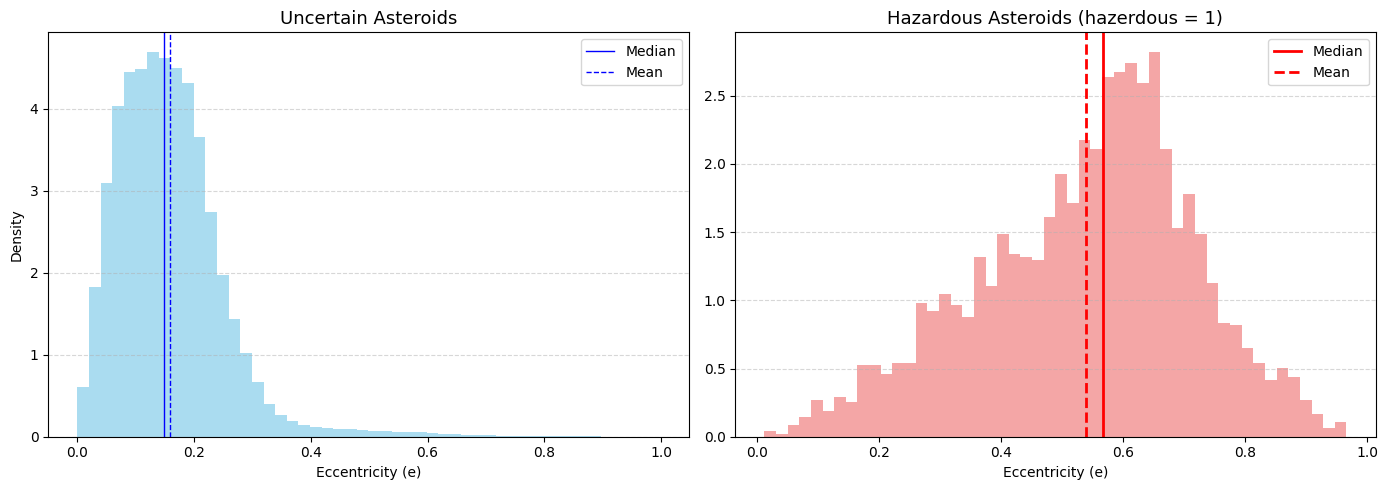

In [231]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(uncertain['e'], bins=50, alpha=0.7, color='skyblue', density=True)
axes[0].set_title('Uncertain Asteroids', fontsize=13)
axes[0].set_xlabel('Eccentricity (e)')
axes[0].set_ylabel('Density')
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

axes[0].axvline(uncertain['e'].median(), color='blue', linestyle='-', linewidth=1, label='Median')
axes[0].axvline(uncertain['e'].mean(), color='blue', linestyle='--', linewidth=1, label='Mean')
axes[0].legend()

axes[1].hist(hazardous['e'], bins=50, alpha=0.7, color='lightcoral', density=True)
axes[1].set_title('Hazardous Asteroids (hazerdous = 1)', fontsize=13)
axes[1].set_xlabel('Eccentricity (e)')
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

axes[1].axvline(hazardous['e'].median(), color='red', linestyle='-', linewidth=2, label='Median')
axes[1].axvline(hazardous['e'].mean(), color='red', linestyle='--', linewidth=2, label='Mean')
axes[1].legend()

plt.tight_layout()
plt.show()


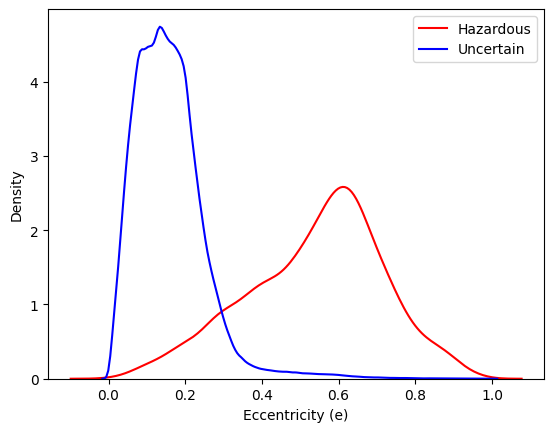

In [232]:
sns.kdeplot(hazardous['e'], color='red', label='Hazardous')
sns.kdeplot(uncertain['e'], color='blue', label='Uncertain')
plt.xlabel('Eccentricity (e)')
plt.ylabel('Density')
plt.legend()
plt.show()

### Distribution of Absolute Magnitude (H)

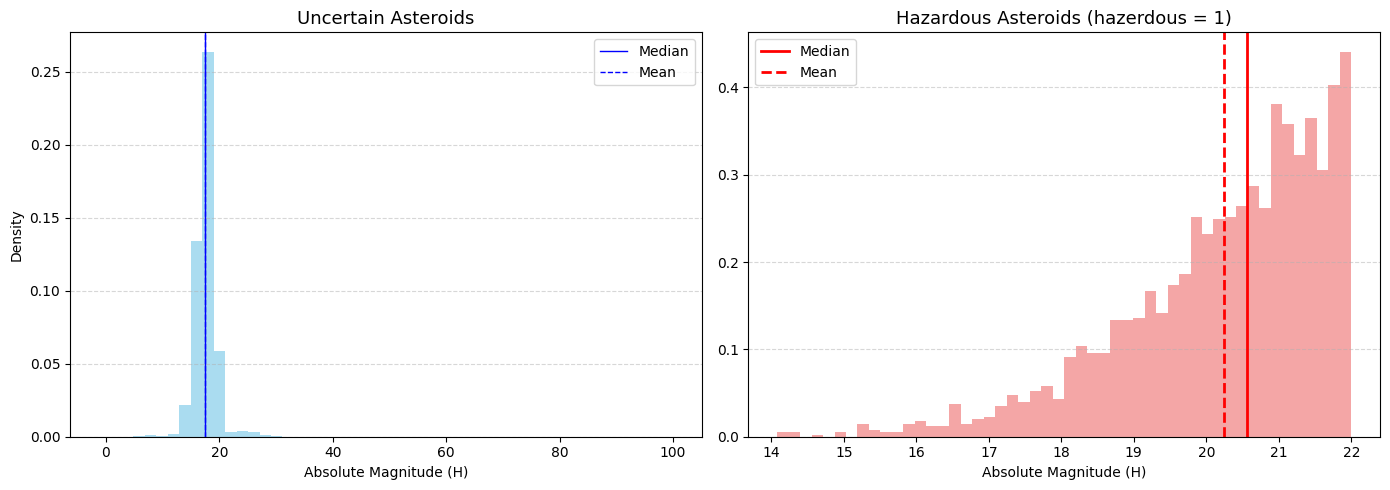

In [233]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(uncertain['H'], bins=50, alpha=0.7, color='skyblue', density=True)
axes[0].set_title('Uncertain Asteroids', fontsize=13)
axes[0].set_xlabel('Absolute Magnitude (H)')
axes[0].set_ylabel('Density')
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

axes[0].axvline(uncertain['H'].median(), color='blue', linestyle='-', linewidth=1, label='Median')
axes[0].axvline(uncertain['H'].mean(), color='blue', linestyle='--', linewidth=1, label='Mean')
axes[0].legend()

axes[1].hist(hazardous['H'], bins=50, alpha=0.7, color='lightcoral', density=True)
axes[1].set_title('Hazardous Asteroids (hazerdous = 1)', fontsize=13)
axes[1].set_xlabel('Absolute Magnitude (H)')
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

axes[1].axvline(hazardous['H'].median(), color='red', linestyle='-', linewidth=2, label='Median')
axes[1].axvline(hazardous['H'].mean(), color='red', linestyle='--', linewidth=2, label='Mean')
axes[1].legend()

plt.tight_layout()
plt.show()


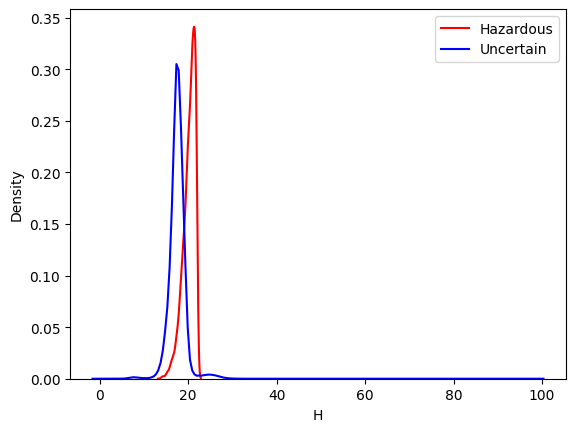

In [234]:
sns.kdeplot(hazardous['H'], color='red', label='Hazardous')
sns.kdeplot(uncertain['H'], color='blue', label='Uncertain')
plt.xlabel('H')
plt.ylabel('Density')
plt.legend()

### Distribution of Mean motion (n)


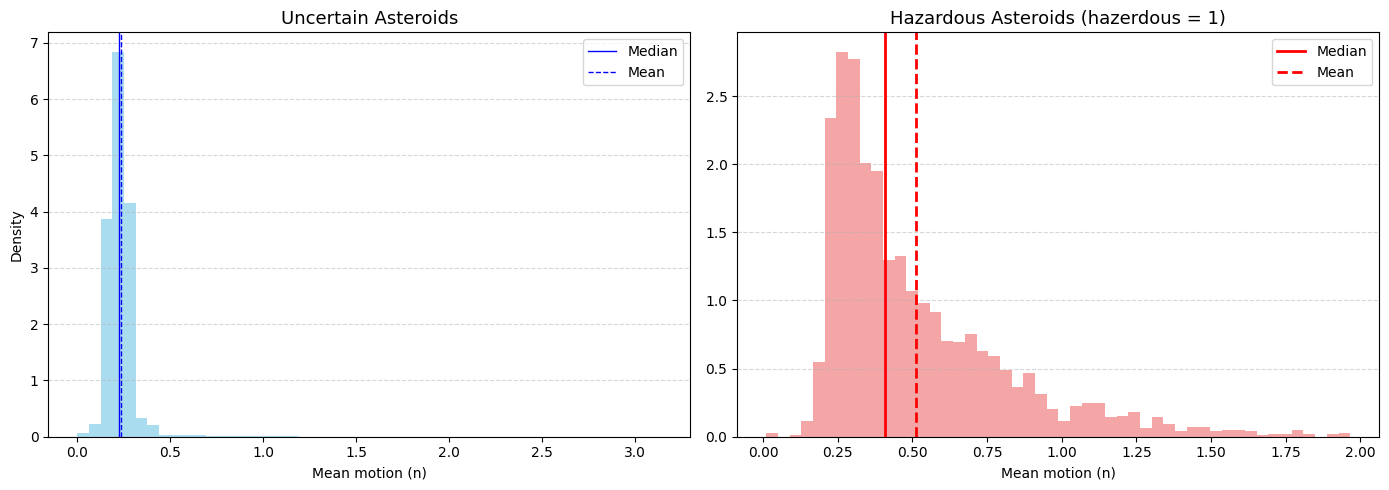

In [235]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(uncertain['n'], bins=50, alpha=0.7, color='skyblue', density=True)
axes[0].set_title('Uncertain Asteroids', fontsize=13)
axes[0].set_xlabel('Mean motion (n)')
axes[0].set_ylabel('Density')
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

axes[0].axvline(uncertain['n'].median(), color='blue', linestyle='-', linewidth=1, label='Median')
axes[0].axvline(uncertain['n'].mean(), color='blue', linestyle='--', linewidth=1, label='Mean')
axes[0].legend()

axes[1].hist(hazardous['n'], bins=50, alpha=0.7, color='lightcoral', density=True)
axes[1].set_title('Hazardous Asteroids (hazerdous = 1)', fontsize=13)
axes[1].set_xlabel('Mean motion (n)')
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

axes[1].axvline(hazardous['n'].median(), color='red', linestyle='-', linewidth=2, label='Median')
axes[1].axvline(hazardous['n'].mean(), color='red', linestyle='--', linewidth=2, label='Mean')
axes[1].legend()

plt.tight_layout()
plt.show()


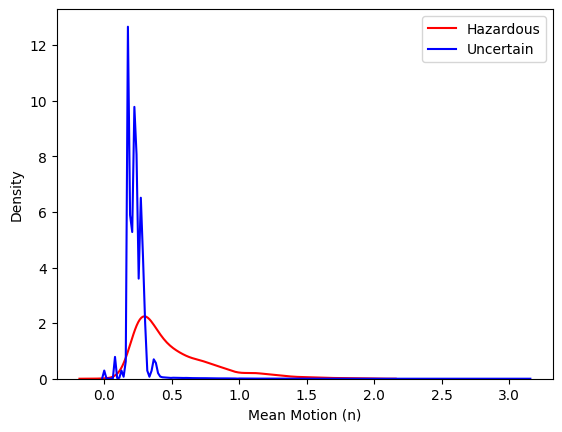

In [236]:
sns.kdeplot(hazardous['n'], color='red', label='Hazardous')
sns.kdeplot(uncertain['n'], color='blue', label='Uncertain')
plt.xlabel('Mean Motion (n)')
plt.ylabel('Density')
plt.legend()
plt.show()

### Distribution of Inclination (i)

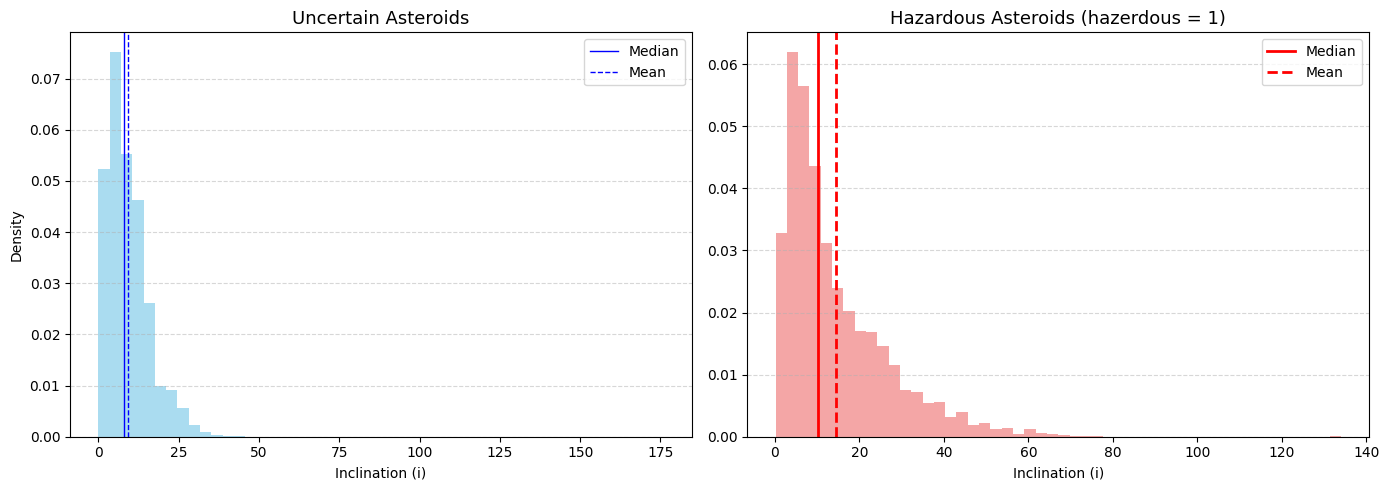

In [237]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(uncertain['i'], bins=50, alpha=0.7, color='skyblue', density=True)
axes[0].set_title('Uncertain Asteroids', fontsize=13)
axes[0].set_xlabel('Inclination (i)')
axes[0].set_ylabel('Density')
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

axes[0].axvline(uncertain['i'].median(), color='blue', linestyle='-', linewidth=1, label='Median')
axes[0].axvline(uncertain['i'].mean(), color='blue', linestyle='--', linewidth=1, label='Mean')
axes[0].legend()

axes[1].hist(hazardous['i'], bins=50, alpha=0.7, color='lightcoral', density=True)
axes[1].set_title('Hazardous Asteroids (hazerdous = 1)', fontsize=13)
axes[1].set_xlabel('Inclination (i)')
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

axes[1].axvline(hazardous['i'].median(), color='red', linestyle='-', linewidth=2, label='Median')
axes[1].axvline(hazardous['i'].mean(), color='red', linestyle='--', linewidth=2, label='Mean')
axes[1].legend()

plt.tight_layout()
plt.show()


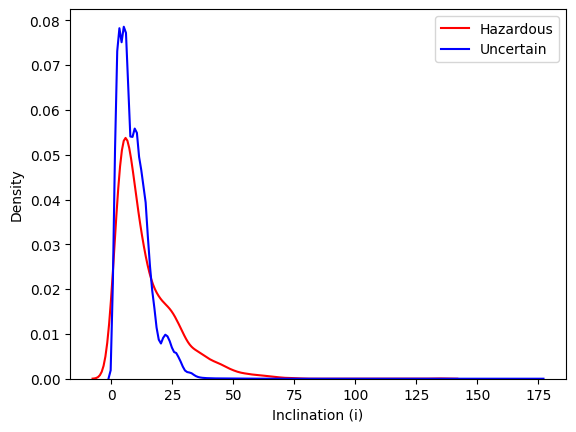

In [238]:
sns.kdeplot(hazardous['i'], color='red', label='Hazardous')
sns.kdeplot(uncertain['i'], color='blue', label='Uncertain')
plt.xlabel('Inclination (i)')
plt.ylabel('Density')
plt.legend()
plt.show()

# Observation quality and hazard label

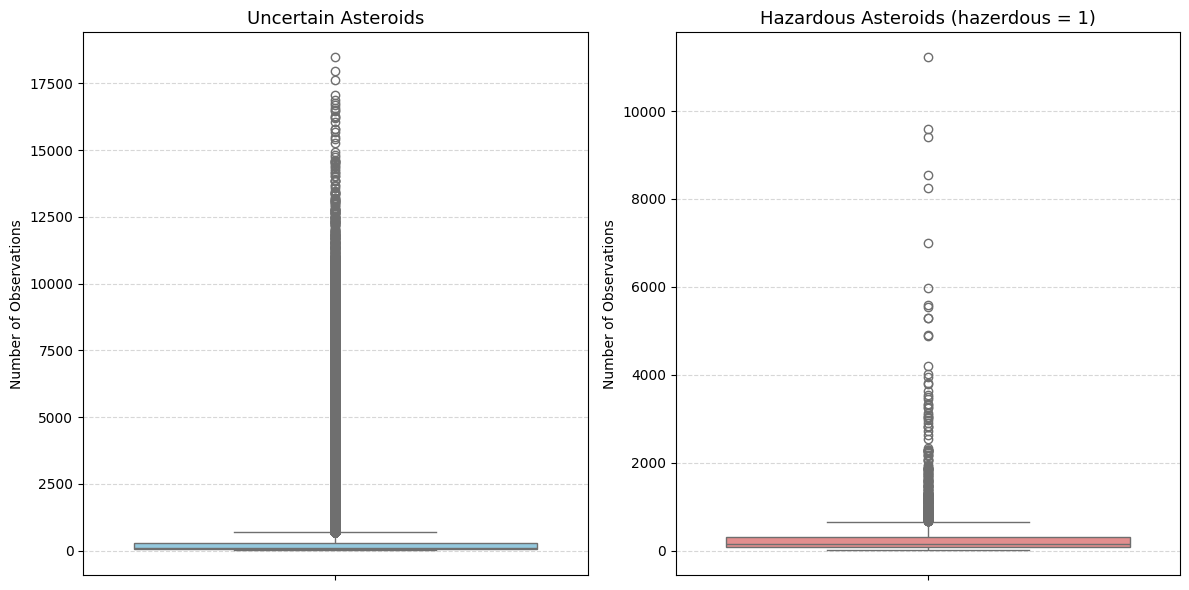

In [239]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))


sns.boxplot(y=uncertain['Num_obs'], color='skyblue', ax=axes[0])
axes[0].set_title('Uncertain Asteroids', fontsize=13)
axes[0].set_ylabel('Number of Observations')
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

sns.boxplot(y=hazardous['Num_obs'], color='lightcoral', ax=axes[1])
axes[1].set_title('Hazardous Asteroids (hazerdous = 1)', fontsize=13)
axes[1].set_ylabel('Number of Observations')
axes[1].grid(axis='y', linestyle='--', alpha=0.5)


plt.tight_layout()
plt.show()


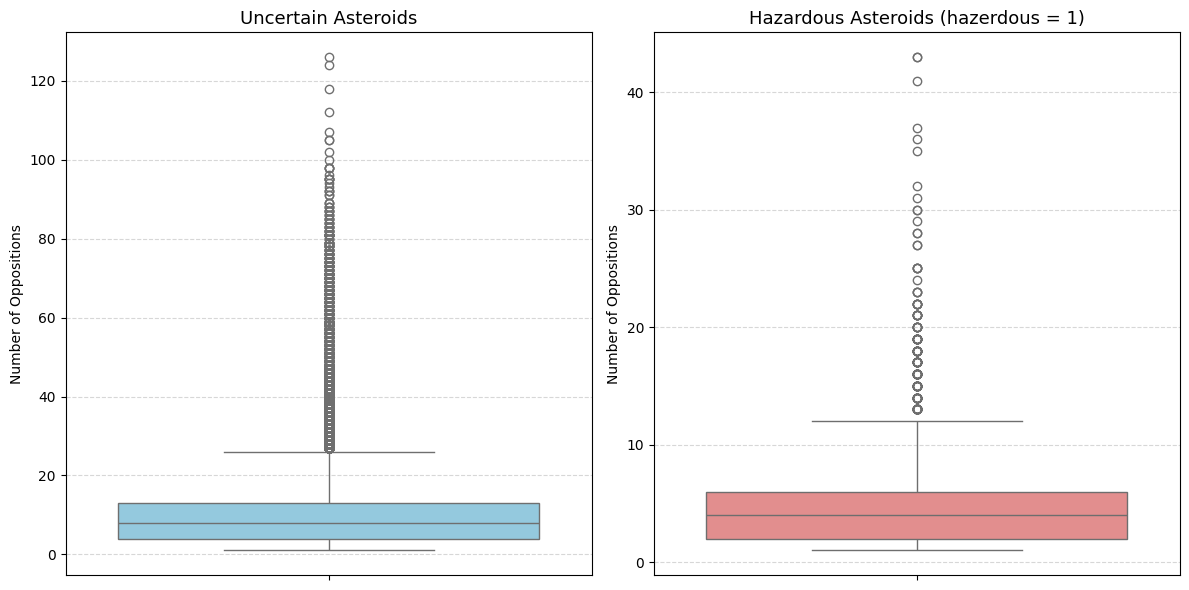

In [240]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

sns.boxplot(y=uncertain['Num_opps'], color='skyblue', ax=axes[0])
axes[0].set_title('Uncertain Asteroids', fontsize=13)
axes[0].set_ylabel('Number of Oppositions')
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

sns.boxplot(y=hazardous['Num_opps'], color='lightcoral', ax=axes[1])
axes[1].set_title('Hazardous Asteroids (hazerdous = 1)', fontsize=13)
axes[1].set_ylabel('Number of Oppositions')
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

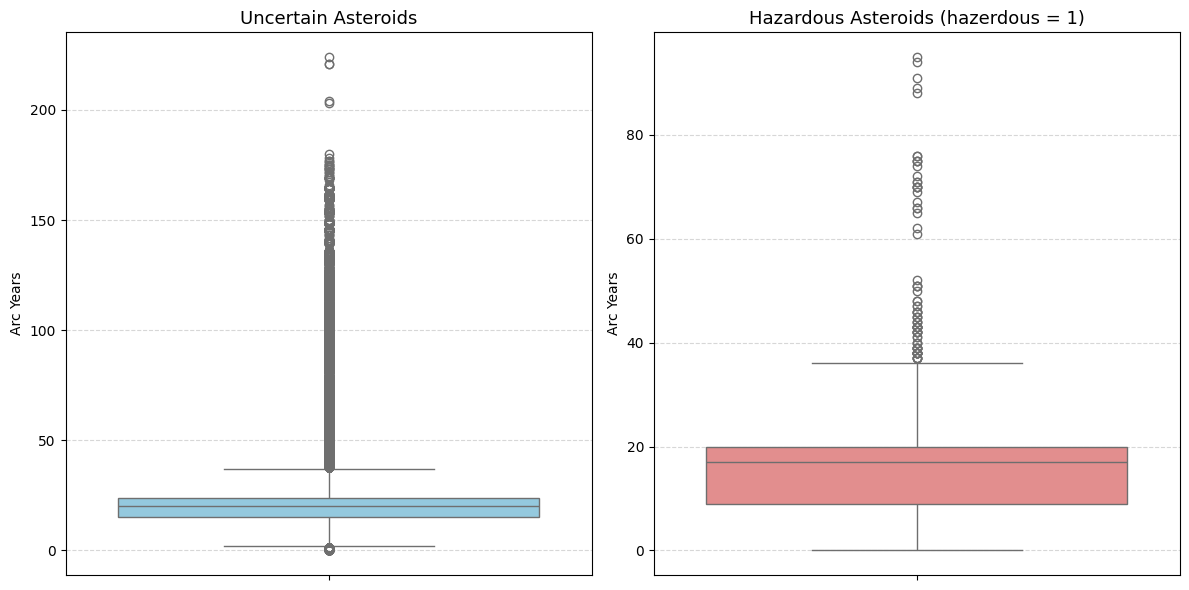

In [241]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

sns.boxplot(y=uncertain['Arc_years'], color='skyblue', ax=axes[0])
axes[0].set_title('Uncertain Asteroids', fontsize=13)
axes[0].set_ylabel('Arc Years')
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

sns.boxplot(y=hazardous['Arc_years'], color='lightcoral', ax=axes[1])
axes[1].set_title('Hazardous Asteroids (hazerdous = 1)', fontsize=13)
axes[1].set_ylabel('Arc Years')
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

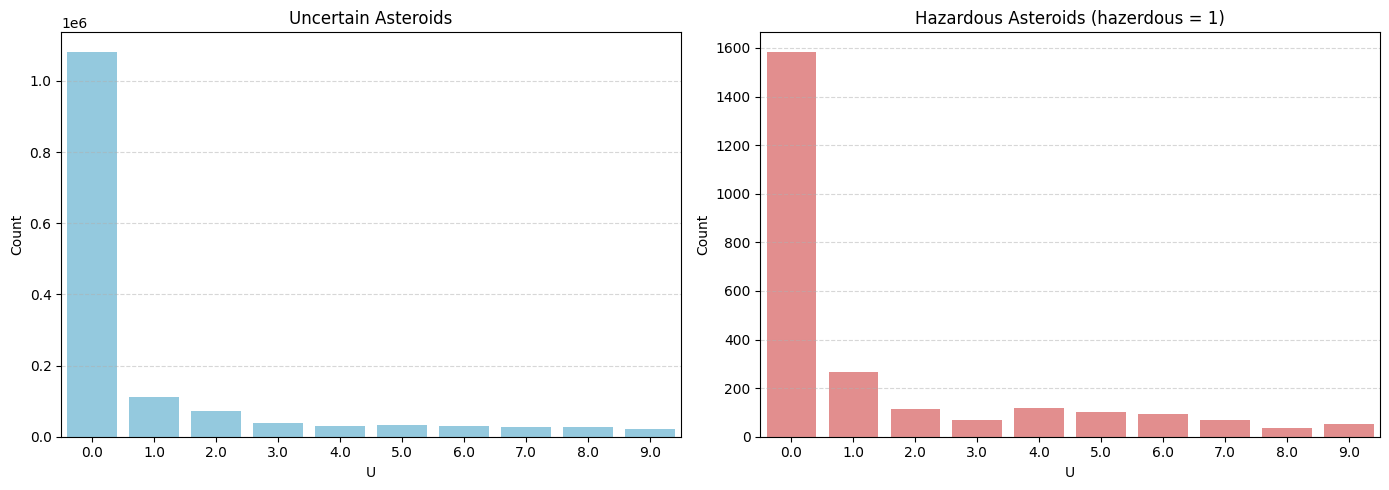

In [242]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

unc_counts = uncertain['U'].value_counts().sort_index()
sns.barplot(x=unc_counts.index, y=unc_counts.values, color='skyblue', ax=axes[0])
axes[0].set_title('Uncertain Asteroids')
axes[0].set_xlabel('U')
axes[0].set_ylabel('Count')
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

haz_counts = hazardous['U'].value_counts().sort_index()
sns.barplot(x=haz_counts.index, y=haz_counts.values, color='lightcoral', ax=axes[1])
axes[1].set_title('Hazardous Asteroids (hazerdous = 1)')
axes[1].set_xlabel('U')
axes[1].set_ylabel('Count')
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# **Data Augmentation**

## Finding uncertain asteroids that are hazardous

In [243]:
df_encoded = pd.get_dummies(df, columns=['Orbit_type'])

In [244]:
df_encoded

,H,G,Num_obs,rms,U,Arc_years,M,Peri,Node,i,e,n,a,Num_opps,Synodic_period,hazerdous,Orbit_type_Amor,Orbit_type_Apollo,Orbit_type_Aten,Orbit_type_Atira,Orbit_type_Distant Object,Orbit_type_Hilda,Orbit_type_Hungaria,Orbit_type_Jupiter Trojan,Orbit_type_MBA,Orbit_type_Phocaea,Orbit_type_perihelion < 1.665 AU
0,18.31,0.15,101.0,0.90,0.0,22.0,98.01667,21.29490,20.45607,2.17419,0.220580,0.236456,2.590018,7,1.315631,0,False,False,False,False,False,False,False,False,True,False,False
1,17.14,0.15,250.0,0.89,0.0,19.0,245.12922,329.93421,318.53094,4.99459,0.125079,0.255371,2.460490,13,1.349710,0,False,False,False,False,False,False,False,False,True,False,False
2,17.12,0.15,213.0,0.99,0.0,17.0,7.73489,333.54655,190.29557,15.46781,0.250532,0.222208,2.699581,9,1.291077,0,False,False,False,False,False,False,False,False,True,False,False
3,18.15,0.15,206.0,0.95,0.0,23.0,227.02952,5.59939,113.34616,2.06068,0.138080,0.273783,2.348900,12,1.384622,0,False,False,False,False,False,False,False,False,True,False,False
4,15.36,0.15,1119.0,0.81,0.0,24.0,296.32977,319.59282,28.96358,14.85383,0.166574,0.230973,2.630845,18,1.306072,0,False,False,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1477085,16.80,0.15,670.0,0.87,0.0,48.0,340.63291,78.86674,221.01017,6.01269,0.123230,0.302369,2.198424,17,1.442552,0,False,False,False,False,False,False,False,False,True,False,False
1477086,16.98,0.15,33.0,0.43,1.0,18.0,92.19696,311.33257,106.21730,4.29026,0.177540,0.124562,3.970799,6,1.144664,0,False,False,False,False,False,True,False,False,False,False,False
1477087,16.79,0.15,598.0,0.80,0.0,27.0,107.25030,27.72002,194.96491,0.79093,0.135780,0.267411,2.386068,18,1.372337,0,False,False,False,False,False,False,False,False,True,False,False
1477088,17.54,0.15,136.0,0.88,0.0,19.0,164.74466,238.79382,81.82374,3.15423,0.069401,0.206451,2.835250,10,1.264967,0,False,False,False,False,False,False,False,False,True,False,False


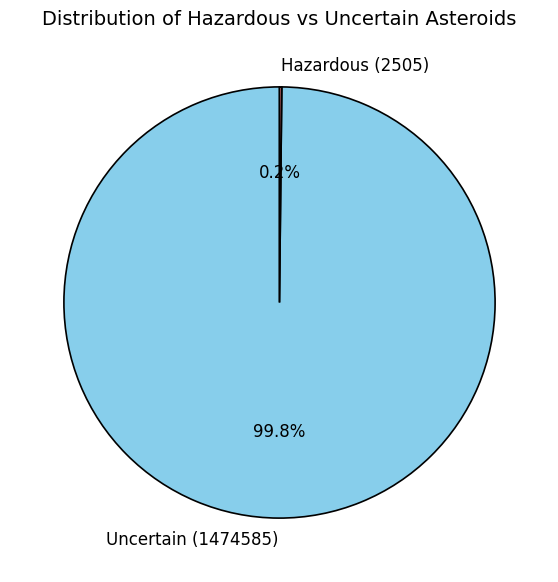

In [245]:
counts = df_encoded['hazerdous'].value_counts()
labels = [f'Uncertain ({counts[0]})', f'Hazardous ({counts[1]})']
colors = ['skyblue', 'lightcoral']

plt.figure(figsize=(7,7))
plt.pie(counts, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90,
        wedgeprops={'edgecolor':'k', 'linewidth':1.2}, textprops={'fontsize':12})
plt.title('Distribution of Hazardous vs Uncertain Asteroids', fontsize=14)
plt.show()

In [249]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

features = ['e', 'i', 'a', 'n', 'Synodic_period', 'H'] + list(df_encoded.filter(like='Orbit_type_').columns)

X_scaled = scaler.fit_transform(df_encoded[features])

In [250]:
X_scaled.shape

(1477090, 17)

In [251]:
X_scaled

array([[ 0.64741567, -1.07711923, -0.04701553, ...,  0.32890878,
        -0.10326502, -0.12924953],
       [-0.35996886, -0.65355299, -0.06587199, ...,  0.32890878,
        -0.10326502, -0.12924953],
       [ 0.96335841,  0.91930984, -0.03106559, ...,  0.32890878,
        -0.10326502, -0.12924953],
       ...,
       [-0.24709141, -1.28485651, -0.07670607, ...,  0.32890878,
        -0.10326502, -0.12924953],
       [-0.94728416, -0.92993732, -0.01131522, ...,  0.32890878,
        -0.10326502, -0.12924953],
       [-0.06382337, -0.90305519, -0.07122603, ...,  0.32890878,
        -0.10326502, -0.12924953]])

In [252]:
from sklearn.neighbors import NearestNeighbors

X_haz = X_scaled[df['hazerdous'] == 1]
X_unc = X_scaled[df['hazerdous'] == 0]

nbrs = NearestNeighbors(n_neighbors=2).fit(X_haz)
distances, indices = nbrs.kneighbors(X_unc)

min_distances = distances.min(axis=1)

In [253]:
print(distances.shape)
print(indices.shape)

(1474585, 2)
(1474585, 2)


In [254]:
min_distances.min(), min_distances.max(), min_distances.mean()

(np.float64(0.06514005230078386),
 np.float64(883.7526248323877),
 np.float64(10.031146536665483))

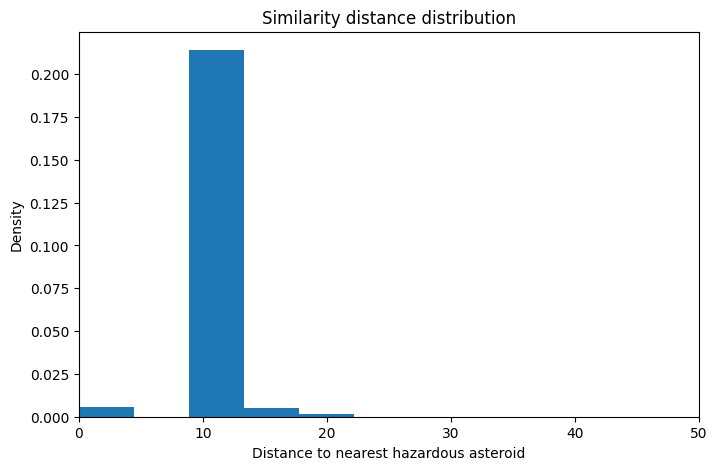

In [255]:
plt.figure(figsize=(8,5))
plt.hist(min_distances, bins=200, density=True)
plt.xlim(0, 50)
plt.xlabel('Distance to nearest hazardous asteroid')
plt.ylabel('Density')
plt.title('Similarity distance distribution')
plt.show()

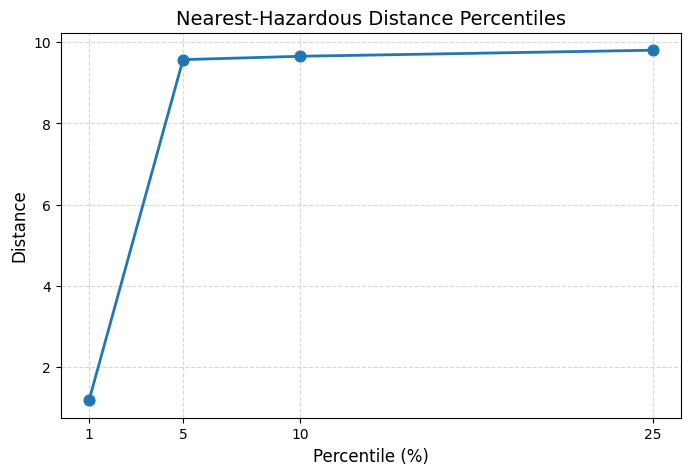

In [256]:
plt.figure(figsize=(8,5))

percentiles = [1, 5, 10, 25]
values = np.percentile(min_distances, percentiles)

plt.plot(percentiles, values, marker='o', linewidth=2)
plt.scatter(percentiles, values, s=60)

plt.xlabel('Percentile (%)', fontsize=12)
plt.ylabel('Distance', fontsize=12)
plt.title('Nearest-Hazardous Distance Percentiles', fontsize=14)

plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(percentiles)

plt.show()

In [257]:
similar_uncertain_threshold_1 = df[df['hazerdous'] == 0].iloc[min_distances < 9.57329289]

similar_uncertain_threshold_2 = df[df['hazerdous'] == 0].iloc[min_distances < 9]

In [258]:
print(similar_uncertain_threshold_1.shape)
print(similar_uncertain_threshold_2.shape)

(73730, 17)
(37334, 17)


In [259]:
similar_uncertain_threshold_1

,H,G,Num_obs,rms,U,Arc_years,M,Peri,Node,i,e,n,a,Num_opps,Synodic_period,Orbit_type,hazerdous
40,28.39,0.15,19.0,0.73,7.0,20.0,191.34006,204.48171,102.95964,2.90437,0.448536,1.570267,0.733084,1,1.685781,Aten,0
47,18.50,0.15,79.0,0.46,2.0,6.0,279.49213,343.81742,55.44248,12.22816,0.326645,0.215918,2.751756,2,1.280526,MBA,0
56,16.58,0.15,590.0,0.86,0.0,64.0,173.08738,237.38744,37.31072,3.70213,0.313131,0.231687,2.625440,17,1.307309,MBA,0
106,19.63,0.15,11.0,0.12,8.0,20.0,193.61403,155.74563,332.90396,6.41731,0.319299,0.229961,2.638555,1,1.304324,MBA,0
108,26.70,0.15,66.0,0.54,1.0,20.0,218.57497,11.27316,341.39881,4.48832,0.586215,0.252330,2.480220,1,1.344112,Amor,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1477054,18.67,0.15,52.0,0.30,1.0,25.0,7.50542,220.60261,183.52300,6.66835,0.307959,0.238269,2.576860,3,1.318824,MBA,0
1477062,23.48,0.15,27.0,0.12,9.0,20.0,237.45762,318.44880,286.99558,16.92708,0.221809,0.662778,1.302839,1,3.053029,Amor,0
1477078,17.90,0.15,140.0,0.55,0.0,13.0,330.64759,187.74604,187.41988,15.94059,0.311538,0.223100,2.692382,3,1.292587,MBA,0
1477080,24.60,0.15,13.0,0.05,6.0,20.0,352.95507,345.32936,232.36224,12.23656,0.284787,0.424224,1.754174,1,1.755675,Amor,0


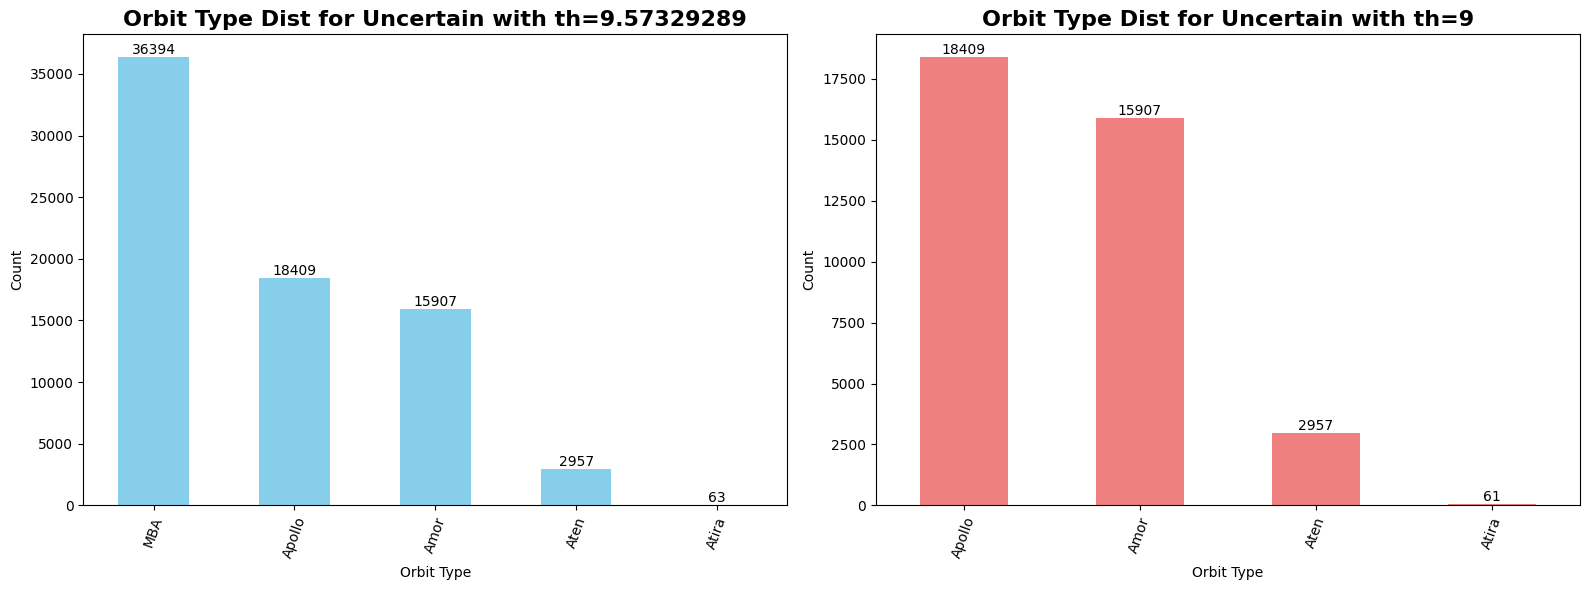

In [260]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))


similar_uncertain_threshold_1['Orbit_type'].value_counts().plot(
    kind='bar', ax=axes[0], color='skyblue'
)
axes[0].set_title('Orbit Type Dist for Uncertain with th=9.57329289',
                  fontweight='bold',
                  fontsize=16
                  )
axes[0].set_xlabel('Orbit Type')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=70)

similar_uncertain_threshold_2['Orbit_type'].value_counts().plot(
    kind='bar', ax=axes[1], color='lightcoral'
)
axes[1].set_title('Orbit Type Dist for Uncertain with th=9',
                  fontweight='bold',
                  fontsize=16
                  )
axes[1].set_xlabel('Orbit Type')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=70)


for ax in axes:
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=10, rotation=0)


plt.tight_layout()
plt.show()


In [261]:
df.loc[similar_uncertain_threshold_2.index, 'hazerdous'] = 1

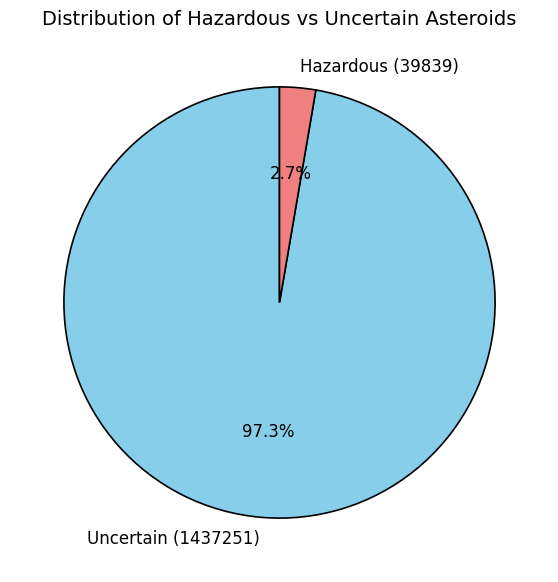

In [262]:
counts = df['hazerdous'].value_counts()
labels = [f'Uncertain ({counts[0]})', f'Hazardous ({counts[1]})']
colors = ['skyblue', 'lightcoral']

plt.figure(figsize=(7,7))
plt.pie(counts, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90,
        wedgeprops={'edgecolor':'k', 'linewidth':1.2}, textprops={'fontsize':12})
plt.title('Distribution of Hazardous vs Uncertain Asteroids', fontsize=14)
plt.show()

## Generating synthetic data

In [263]:
core_features = ['a','e','i','H','Num_obs','Num_opps','Arc_years']
haz = df[df['hazerdous'] == 1][core_features]

In [264]:
haz.shape

(39839, 7)

In [265]:
from sklearn.neighbors import KernelDensity

kde = KernelDensity(
    kernel='gaussian',
    bandwidth=0.15
)

kde.fit(haz)

KernelDensity(bandwidth=0.15)

In [266]:
new_core = kde.sample(100_000)
new_core = pd.DataFrame(new_core, columns=core_features)

In [267]:
new_core['e'] = new_core['e'].clip(0, 0.999)
new_core['a'] = new_core['a'].clip(lower=0.5)
new_core['i'] = new_core['i'].clip(0, 180)
new_core['H'] = new_core['H'].clip(5, 35)

In [268]:
new = new_core.copy()

new['n'] = 360 / (new['a'] ** 1.5)
new['Synodic_period'] = 1 / np.abs(1 - 1 / (new['a'] ** 1.5))

In [269]:
meta_cols = ['Orbit_type','M','Peri','Node','U','G','rms']

meta = df[df['hazerdous'] == 1][meta_cols] \
         .sample(len(new), replace=True) \
         .reset_index(drop=True)

new = pd.concat([new.reset_index(drop=True), meta], axis=1)
new['hazerdous'] = 1

In [270]:
new

,a,e,i,H,Num_obs,Num_opps,Arc_years,n,Synodic_period,Orbit_type,M,Peri,Node,U,G,rms,hazerdous
0,1.692365,0.524479,34.347799,20.403502,75.093991,3.824297,2.978690,163.516380,1.832214,Apollo,265.27246,210.90500,58.89844,9.0,0.15,0.62,1
1,0.950209,0.075065,2.666200,26.346028,147.118305,1.317942,19.949792,388.663369,12.559584,Amor,65.09775,352.31307,51.74625,0.0,0.15,0.68,1
2,1.570754,0.124823,16.941434,24.315048,27.307866,0.954182,19.781181,182.868977,2.032394,Amor,246.66808,199.22361,97.25659,1.0,0.15,0.45,1
3,1.120628,0.036423,2.413534,26.967429,95.958748,0.670217,19.730269,303.466330,6.367887,Amor,123.16334,191.03561,298.84714,7.0,0.15,0.62,1
4,2.376995,0.777454,2.538191,26.319248,64.859582,0.758217,19.853078,98.233596,1.375272,Amor,93.45840,8.64509,23.07840,5.0,0.15,0.69,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,1.486472,0.270012,4.802694,25.813218,42.293214,0.915732,20.045526,198.640261,2.231040,Amor,88.17572,110.71598,324.08144,0.0,0.15,0.81,1
99996,0.924918,0.334034,21.295804,26.358400,26.926251,1.084334,20.053725,404.713386,8.051280,Amor,357.38381,187.89708,319.80423,7.0,0.15,0.97,1
99997,1.626050,0.352890,18.779108,21.172649,33.969306,1.075911,19.996479,173.620707,1.931545,Apollo,308.91644,85.88035,49.98403,7.0,0.15,0.99,1
99998,1.855748,0.253136,8.814547,28.655258,15.870719,1.033025,20.000418,142.404584,1.654447,Apollo,27.83667,273.71707,268.89582,0.0,0.15,0.80,1


In [271]:
new = new[df.columns]

In [272]:
new

,H,G,Num_obs,rms,U,Arc_years,M,Peri,Node,i,e,n,a,Num_opps,Synodic_period,Orbit_type,hazerdous
0,20.403502,0.15,75.093991,0.62,9.0,2.978690,265.27246,210.90500,58.89844,34.347799,0.524479,163.516380,1.692365,3.824297,1.832214,Apollo,1
1,26.346028,0.15,147.118305,0.68,0.0,19.949792,65.09775,352.31307,51.74625,2.666200,0.075065,388.663369,0.950209,1.317942,12.559584,Amor,1
2,24.315048,0.15,27.307866,0.45,1.0,19.781181,246.66808,199.22361,97.25659,16.941434,0.124823,182.868977,1.570754,0.954182,2.032394,Amor,1
3,26.967429,0.15,95.958748,0.62,7.0,19.730269,123.16334,191.03561,298.84714,2.413534,0.036423,303.466330,1.120628,0.670217,6.367887,Amor,1
4,26.319248,0.15,64.859582,0.69,5.0,19.853078,93.45840,8.64509,23.07840,2.538191,0.777454,98.233596,2.376995,0.758217,1.375272,Amor,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,25.813218,0.15,42.293214,0.81,0.0,20.045526,88.17572,110.71598,324.08144,4.802694,0.270012,198.640261,1.486472,0.915732,2.231040,Amor,1
99996,26.358400,0.15,26.926251,0.97,7.0,20.053725,357.38381,187.89708,319.80423,21.295804,0.334034,404.713386,0.924918,1.084334,8.051280,Amor,1
99997,21.172649,0.15,33.969306,0.99,7.0,19.996479,308.91644,85.88035,49.98403,18.779108,0.352890,173.620707,1.626050,1.075911,1.931545,Apollo,1
99998,28.655258,0.15,15.870719,0.80,0.0,20.000418,27.83667,273.71707,268.89582,8.814547,0.253136,142.404584,1.855748,1.033025,1.654447,Apollo,1


In [273]:
df

,H,G,Num_obs,rms,U,Arc_years,M,Peri,Node,i,e,n,a,Num_opps,Synodic_period,Orbit_type,hazerdous
0,18.31,0.15,101.0,0.90,0.0,22.0,98.01667,21.29490,20.45607,2.17419,0.220580,0.236456,2.590018,7,1.315631,MBA,0
1,17.14,0.15,250.0,0.89,0.0,19.0,245.12922,329.93421,318.53094,4.99459,0.125079,0.255371,2.460490,13,1.349710,MBA,0
2,17.12,0.15,213.0,0.99,0.0,17.0,7.73489,333.54655,190.29557,15.46781,0.250532,0.222208,2.699581,9,1.291077,MBA,0
3,18.15,0.15,206.0,0.95,0.0,23.0,227.02952,5.59939,113.34616,2.06068,0.138080,0.273783,2.348900,12,1.384622,MBA,0
4,15.36,0.15,1119.0,0.81,0.0,24.0,296.32977,319.59282,28.96358,14.85383,0.166574,0.230973,2.630845,18,1.306072,MBA,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1477085,16.80,0.15,670.0,0.87,0.0,48.0,340.63291,78.86674,221.01017,6.01269,0.123230,0.302369,2.198424,17,1.442552,MBA,0
1477086,16.98,0.15,33.0,0.43,1.0,18.0,92.19696,311.33257,106.21730,4.29026,0.177540,0.124562,3.970799,6,1.144664,Hilda,0
1477087,16.79,0.15,598.0,0.80,0.0,27.0,107.25030,27.72002,194.96491,0.79093,0.135780,0.267411,2.386068,18,1.372337,MBA,0
1477088,17.54,0.15,136.0,0.88,0.0,19.0,164.74466,238.79382,81.82374,3.15423,0.069401,0.206451,2.835250,10,1.264967,MBA,0


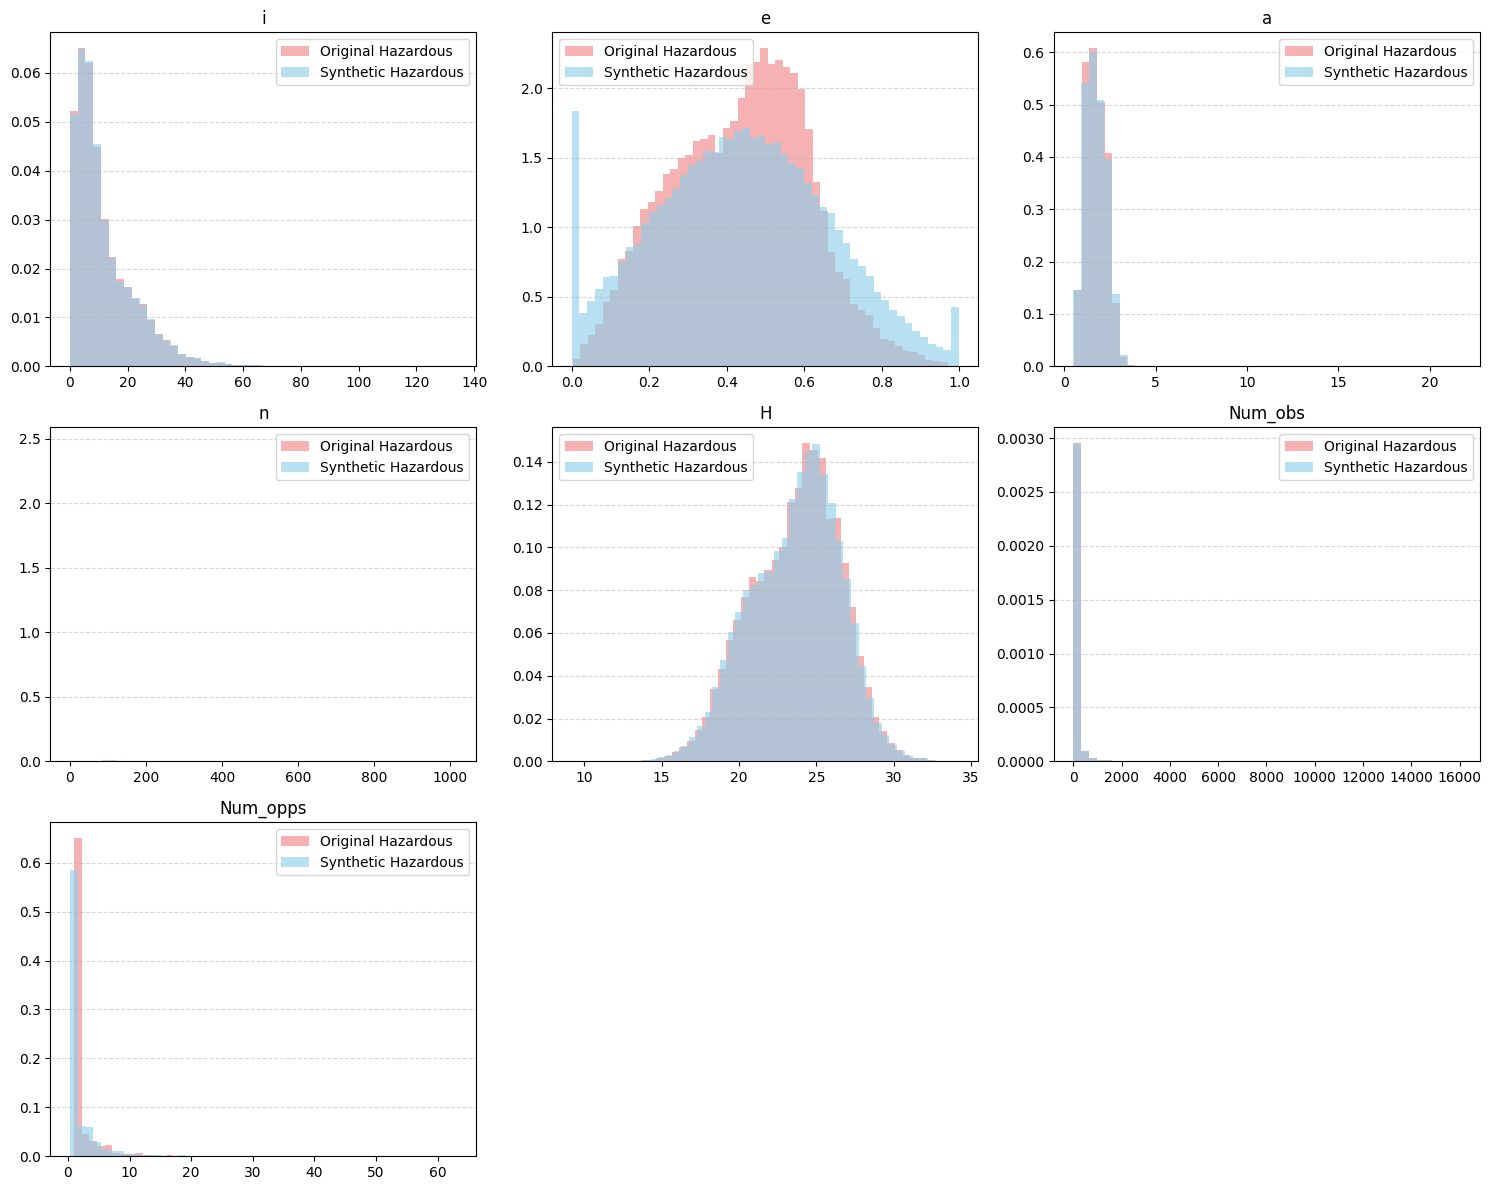

In [274]:
cols = ['i','e','a','n','H','Num_obs','Num_opps']
n_cols = 3
n_rows = (len(cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
axes = axes.flatten()

for ax, col in zip(axes, cols):
    ax.hist(df[df['hazerdous']==1][col], bins=50, alpha=0.6, color='lightcoral', density=True, label='Original Hazardous')
    ax.hist(new[col], bins=50, alpha=0.6, color='skyblue', density=True, label='Synthetic Hazardous')
    ax.set_title(col)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    ax.legend()

for ax in axes[len(cols):]:
    ax.remove()

plt.tight_layout()
plt.show()

In [275]:
df_augmented = pd.concat([df, new], ignore_index=True)

In [276]:
df_augmented

,H,G,Num_obs,rms,U,Arc_years,M,Peri,Node,i,e,n,a,Num_opps,Synodic_period,Orbit_type,hazerdous
0,18.310000,0.15,101.000000,0.90,0.0,22.000000,98.01667,21.29490,20.45607,2.174190,0.220580,0.236456,2.590018,7.000000,1.315631,MBA,0
1,17.140000,0.15,250.000000,0.89,0.0,19.000000,245.12922,329.93421,318.53094,4.994590,0.125079,0.255371,2.460490,13.000000,1.349710,MBA,0
2,17.120000,0.15,213.000000,0.99,0.0,17.000000,7.73489,333.54655,190.29557,15.467810,0.250532,0.222208,2.699581,9.000000,1.291077,MBA,0
3,18.150000,0.15,206.000000,0.95,0.0,23.000000,227.02952,5.59939,113.34616,2.060680,0.138080,0.273783,2.348900,12.000000,1.384622,MBA,0
4,15.360000,0.15,1119.000000,0.81,0.0,24.000000,296.32977,319.59282,28.96358,14.853830,0.166574,0.230973,2.630845,18.000000,1.306072,MBA,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1577085,25.813218,0.15,42.293214,0.81,0.0,20.045526,88.17572,110.71598,324.08144,4.802694,0.270012,198.640261,1.486472,0.915732,2.231040,Amor,1
1577086,26.358400,0.15,26.926251,0.97,7.0,20.053725,357.38381,187.89708,319.80423,21.295804,0.334034,404.713386,0.924918,1.084334,8.051280,Amor,1
1577087,21.172649,0.15,33.969306,0.99,7.0,19.996479,308.91644,85.88035,49.98403,18.779108,0.352890,173.620707,1.626050,1.075911,1.931545,Apollo,1
1577088,28.655258,0.15,15.870719,0.80,0.0,20.000418,27.83667,273.71707,268.89582,8.814547,0.253136,142.404584,1.855748,1.033025,1.654447,Apollo,1


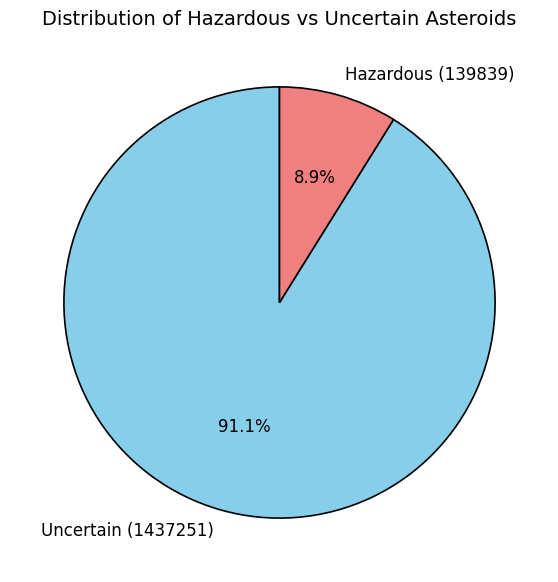

In [277]:
counts = df_augmented['hazerdous'].value_counts()
labels = [f'Uncertain ({counts[0]})', f'Hazardous ({counts[1]})']
colors = ['skyblue', 'lightcoral']

plt.figure(figsize=(7,7))
plt.pie(counts, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90,
        wedgeprops={'edgecolor':'k', 'linewidth':1.2}, textprops={'fontsize':12})
plt.title('Distribution of Hazardous vs Uncertain Asteroids', fontsize=14)
plt.show()

In [278]:
haz = df_augmented[df_augmented['hazerdous']==1]
unc = df_augmented[(df_augmented['hazerdous'] == 0)]


unc_filtered = unc[(unc['Orbit_type'] != 'MBA') | (unc['Orbit_type'] == 'MBA')].sample(
    frac=0.1,
    random_state=42
)


df_balanced = pd.concat([haz, unc_filtered])


In [279]:
haz.shape

(139839, 17)

In [280]:
df_balanced.reset_index(drop=True, inplace=True)

In [281]:
df_balanced

,H,G,Num_obs,rms,U,Arc_years,M,Peri,Node,i,e,n,a,Num_opps,Synodic_period,Orbit_type,hazerdous
0,28.39,0.15,19.0,0.73,7.0,20.0,191.34006,204.48171,102.95964,2.90437,0.448536,1.570267,0.733084,1.0,1.685781,Aten,1
1,26.70,0.15,66.0,0.54,1.0,20.0,218.57497,11.27316,341.39881,4.48832,0.586215,0.252330,2.480220,1.0,1.344112,Amor,1
2,26.63,0.15,19.0,1.11,8.0,20.0,140.54850,2.34323,115.22023,7.33239,0.241731,0.613903,1.371102,1.0,2.651586,Amor,1
3,18.41,0.15,65.0,0.93,3.0,1.0,322.40083,134.92355,325.58346,47.76842,0.745866,0.186487,3.034151,2.0,1.233365,Apollo,1
4,25.70,0.15,70.0,0.30,6.0,20.0,329.13080,279.05428,233.60578,1.20353,0.236929,1.201921,0.876097,1.0,4.556384,Aten,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
283559,18.24,0.15,53.0,0.51,0.0,21.0,198.90284,3.20210,169.26556,7.23360,0.118078,0.239664,2.566854,7.0,1.321289,MBA,0
283560,18.30,0.15,116.0,0.63,0.0,24.0,246.03905,170.18415,251.82936,2.09233,0.158093,0.229166,2.644660,10.0,1.302952,MBA,0
283561,16.67,0.15,159.0,0.91,0.0,22.0,100.22366,356.85065,3.59370,9.86821,0.215838,0.182051,3.083238,7.0,1.226557,MBA,0
283562,17.67,0.15,138.0,0.95,0.0,17.0,70.49055,27.81745,337.31636,11.07776,0.229780,0.228931,2.646463,6.0,1.302549,MBA,0


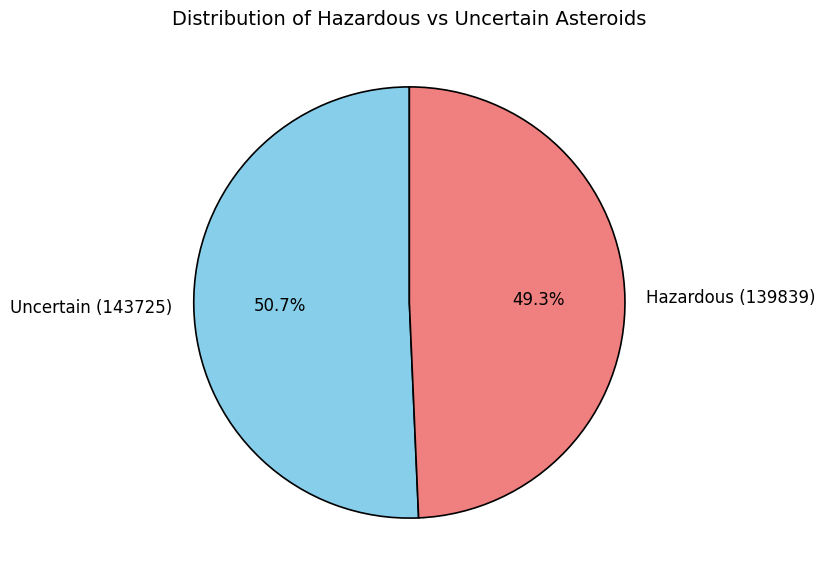

In [282]:
counts = df_balanced['hazerdous'].value_counts()
labels = [f'Uncertain ({counts[0]})', f'Hazardous ({counts[1]})']
colors = ['skyblue', 'lightcoral']

plt.figure(figsize=(7,7))
plt.pie(counts, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90,
        wedgeprops={'edgecolor':'k', 'linewidth':1.2}, textprops={'fontsize':12})
plt.title('Distribution of Hazardous vs Uncertain Asteroids', fontsize=14)
plt.show()

In [283]:
hazardous = df_balanced[df_balanced['hazerdous'] == 1]

uncertain = df_balanced[df_balanced['hazerdous'] == 0]

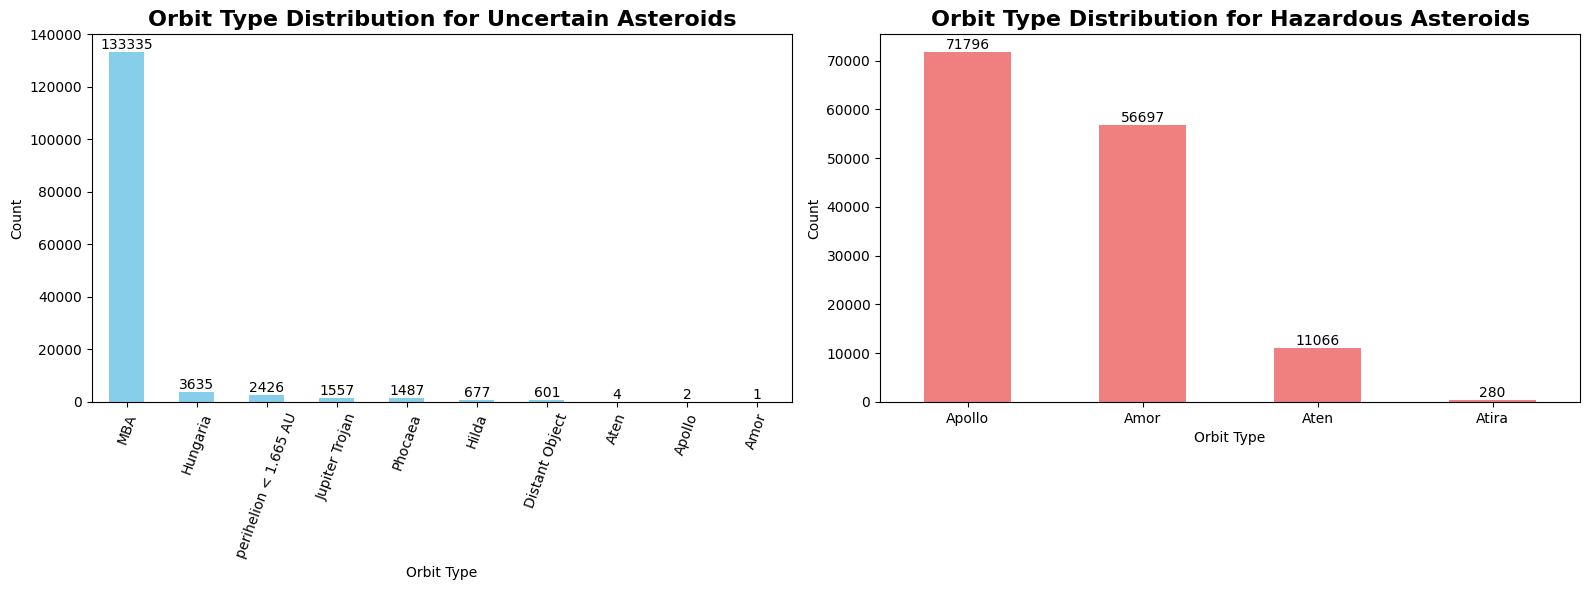

In [284]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))


uncertain['Orbit_type'].value_counts().plot(
    kind='bar', ax=axes[0], color='skyblue'
)
axes[0].set_title('Orbit Type Distribution for Uncertain Asteroids',
                  fontweight='bold',
                  fontsize=16
                  )
axes[0].set_xlabel('Orbit Type')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=70)

hazardous['Orbit_type'].value_counts().plot(
    kind='bar', ax=axes[1], color='lightcoral'
)
axes[1].set_title('Orbit Type Distribution for Hazardous Asteroids',
                  fontweight='bold',
                  fontsize=16
                  )
axes[1].set_xlabel('Orbit Type')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)

for ax in axes:
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=10, rotation=0)


plt.tight_layout()
plt.show()

In [285]:
df_balanced.to_csv('/content/drive/MyDrive/Colab Notebooks/Personal/asteroid_project/data/processed/model_ready.csv', index=False)